# Structured Products Pricer — Notebook complet v3

Cette version intègre les dernières améliorations du projet :

- inventaire product-level via `build_pricing_inventory()` ;
- loader dans `src.portfolio.inventory_loader` ;
- support `BasisSwap` ;
- quantités négatives via `position_sign` ;
- surface de volatilité standardisée avec `volatility(...)` ;
- `NumericalGreeksEngine` corrigé pour bumper aussi les paramètres portés par le modèle ;
- `PortfolioPricingEngine` avec activation optionnelle des Greeks numériques ;
- `StressTester` finalisé pour scénarios spot / vol / taux ;
- exports pour dashboard.

Ce notebook est conçu pour être utilisé comme support complet de démonstration, validation et préparation dashboard.


## 0. Setup projet

### Attendu

La cellule doit afficher :

```text
src exists: True
```

Si ce n'est pas le cas, modifier manuellement `PROJECT_ROOT`.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import os
import platform
import warnings

warnings.filterwarnings("ignore")

def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / "src").exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root()

# Si nécessaire :
# PROJECT_ROOT = Path(r"C:/Users/alixg/.../structured-products-pricer").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Python:", platform.python_version())
print("src exists:", (PROJECT_ROOT / "src").exists())


PROJECT_ROOT: C:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Produits Structurés\Projet\structured-products-pricer
Python: 3.14.3
src exists: True


## 1. Imports standards et helpers

### Attendu

Les imports standards doivent passer.  
Les helpers servent à vérifier les modules, afficher des tableaux et comparer attendu/obtenu.


In [2]:
import math
import traceback
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

def try_import(path: str):
    try:
        module_path, symbol = path.rsplit(".", 1)
        module = __import__(module_path, fromlist=[symbol])
        return getattr(module, symbol), None
    except Exception as exc:
        return None, exc

def status_row(name: str, obj: Any, err: Exception | None = None) -> dict[str, Any]:
    return {
        "module": name,
        "available": obj is not None,
        "status": "OK" if obj is not None else "WARN",
        "details": "" if err is None else str(err),
    }

def safe_head(title: str, frame: pd.DataFrame, n: int = 10):
    print(f"\n--- {title} ---")
    display(frame.head(n))
    print("shape =", frame.shape)

def compare_value(check: str, obtained: float, expected: float, tolerance: float) -> dict[str, Any]:
    diff = float(obtained - expected)
    return {
        "check": check,
        "obtained": obtained,
        "expected": expected,
        "abs_diff": abs(diff),
        "tolerance": tolerance,
        "status": "PASS" if abs(diff) <= tolerance else "WARN",
    }

def finite_ratio(series: pd.Series) -> float:
    values = pd.to_numeric(series, errors="coerce")
    return float(np.isfinite(values).mean()) if len(values) else 0.0


## 2. Imports projet

### Attendu

Les modules critiques doivent être en `OK`.

Points importants :

- `src.portfolio.inventory_loader.build_pricing_inventory` doit être disponible ;
- `src.products.basis_swap.BasisSwap` doit être disponible ;
- `src.risk.numerical_greeks.NumericalGreeksEngine` doit être disponible ;
- `src.risk.stress_testing.StressTester` doit être disponible ;
- `maturity_bucket` et `strike_bucket` doivent être exportés par `pricing_engine.py`.


In [3]:
imports = []

# Config / marché
ProjectConfig, e = try_import("src.config.ProjectConfig")
imports.append(status_row("ProjectConfig", ProjectConfig, e))

MarketData, e = try_import("src.market.market_data.MarketData")
imports.append(status_row("MarketData", MarketData, e))

YieldCurve, e = try_import("src.rates.yield_curve.YieldCurve")
imports.append(status_row("YieldCurve", YieldCurve, e))

build_spot_by_underlying, e = try_import("src.market.market_context.build_spot_by_underlying")
imports.append(status_row("build_spot_by_underlying", build_spot_by_underlying, e))

build_volatility_by_underlying, e = try_import("src.market.market_context.build_volatility_by_underlying")
imports.append(status_row("build_volatility_by_underlying", build_volatility_by_underlying, e))

# Loader portfolio
load_inventory_workbook, e = try_import("src.portfolio.inventory_loader.load_inventory_workbook")
imports.append(status_row("load_inventory_workbook", load_inventory_workbook, e))

combine_inventory_sheets, e = try_import("src.portfolio.inventory_loader.combine_inventory_sheets")
imports.append(status_row("combine_inventory_sheets", combine_inventory_sheets, e))

build_pricing_inventory, e = try_import("src.portfolio.inventory_loader.build_pricing_inventory")
imports.append(status_row("build_pricing_inventory", build_pricing_inventory, e))

inventory_dataset_summary, e = try_import("src.portfolio.inventory_loader.inventory_dataset_summary")
imports.append(status_row("inventory_dataset_summary", inventory_dataset_summary, e))

# Produits
VanillaOption, e = try_import("src.products.vanilla_option.VanillaOption")
imports.append(status_row("VanillaOption", VanillaOption, e))

ZeroCouponBond, e = try_import("src.products.zero_coupon_bond.ZeroCouponBond")
imports.append(status_row("ZeroCouponBond", ZeroCouponBond, e))

CouponBond, e = try_import("src.products.coupon_bond.CouponBond")
imports.append(status_row("CouponBond", CouponBond, e))

InterestRateSwap, e = try_import("src.products.swap.InterestRateSwap")
imports.append(status_row("InterestRateSwap", InterestRateSwap, e))

BasisSwap, e = try_import("src.products.basis_swap.BasisSwap")
imports.append(status_row("BasisSwap", BasisSwap, e))

BarrierOption, e = try_import("src.products.barrier_option.BarrierOption")
imports.append(status_row("BarrierOption", BarrierOption, e))

AutocallProduct, e = try_import("src.products.autocall.AutocallProduct")
imports.append(status_row("AutocallProduct", AutocallProduct, e))

CallSpread, e = try_import("src.products.option_strategies.CallSpread")
imports.append(status_row("CallSpread", CallSpread, e))

PutSpread, e = try_import("src.products.option_strategies.PutSpread")
imports.append(status_row("PutSpread", PutSpread, e))

Butterfly, e = try_import("src.products.option_strategies.Butterfly")
imports.append(status_row("Butterfly", Butterfly, e))

Straddle, e = try_import("src.products.option_strategies.Straddle")
imports.append(status_row("Straddle", Straddle, e))

# Modèles
BlackScholesModel, e = try_import("src.models.black_scholes.BlackScholesModel")
imports.append(status_row("BlackScholesModel", BlackScholesModel, e))

black_scholes_price_and_greeks, e = try_import("src.models.black_scholes.black_scholes_price_and_greeks")
imports.append(status_row("black_scholes_price_and_greeks", black_scholes_price_and_greeks, e))

DiscountingModel, e = try_import("src.models.discounting_model.DiscountingModel")
imports.append(status_row("DiscountingModel", DiscountingModel, e))

BarrierModel, e = try_import("src.models.barrier_model.BarrierModel")
imports.append(status_row("BarrierModel", BarrierModel, e))

MonteCarloGBMModel, e = try_import("src.models.monte_carlo.MonteCarloGBMModel")
imports.append(status_row("MonteCarloGBMModel", MonteCarloGBMModel, e))

StaticReplicationModel, e = try_import("src.models.static_replication.StaticReplicationModel")
imports.append(status_row("StaticReplicationModel", StaticReplicationModel, e))

# Factory / router
build_product_from_row, e = try_import("src.factory.builders.build_product_from_row")
imports.append(status_row("build_product_from_row", build_product_from_row, e))

create_default_product_registry, e = try_import("src.factory.builders.create_default_product_registry")
imports.append(status_row("create_default_product_registry", create_default_product_registry, e))

PricingRouter, e = try_import("src.factory.pricing_router.PricingRouter")
imports.append(status_row("PricingRouter", PricingRouter, e))

# Calibration vol
calibrate_implied_vol_panel, e = try_import("src.calibration.implied_vol.calibrate_implied_vol_panel")
imports.append(status_row("calibrate_implied_vol_panel", calibrate_implied_vol_panel, e))

ImpliedVolSurface, e = try_import("src.calibration.implied_vol.ImpliedVolSurface")
imports.append(status_row("ImpliedVolSurface", ImpliedVolSurface, e))

build_surface_grid, e = try_import("src.calibration.implied_vol.build_surface_grid")
imports.append(status_row("build_surface_grid", build_surface_grid, e))

# Market loaders
load_rate_curves, e = try_import("src.market.loaders.load_rate_curves")
if load_rate_curves is None:
    load_rate_curves, e = try_import("src.data.loaders.load_rate_curves")
imports.append(status_row("load_rate_curves", load_rate_curves, e))

load_option_quotes, e = try_import("src.market.loaders.load_option_quotes")
if load_option_quotes is None:
    load_option_quotes, e = try_import("src.data.loaders.load_option_quotes")
imports.append(status_row("load_option_quotes", load_option_quotes, e))

# Portfolio / risk
PortfolioPricingEngine, e = try_import("src.portfolio.pricing_engine.PortfolioPricingEngine")
imports.append(status_row("PortfolioPricingEngine", PortfolioPricingEngine, e))

PortfolioPricingConfig, e = try_import("src.portfolio.pricing_engine.PortfolioPricingConfig")
imports.append(status_row("PortfolioPricingConfig", PortfolioPricingConfig, e))

maturity_bucket, e = try_import("src.portfolio.pricing_engine.maturity_bucket")
imports.append(status_row("maturity_bucket", maturity_bucket, e))

strike_bucket, e = try_import("src.portfolio.pricing_engine.strike_bucket")
imports.append(status_row("strike_bucket", strike_bucket, e))

RiskAggregator, e = try_import("src.risk.aggregator.RiskAggregator")
imports.append(status_row("RiskAggregator", RiskAggregator, e))

RiskSnapshot, e = try_import("src.risk.report.RiskSnapshot")
imports.append(status_row("RiskSnapshot", RiskSnapshot, e))

PortfolioRiskReport, e = try_import("src.risk.report.PortfolioRiskReport")
imports.append(status_row("PortfolioRiskReport", PortfolioRiskReport, e))

NumericalGreeksConfig, e = try_import("src.risk.numerical_greeks.NumericalGreeksConfig")
imports.append(status_row("NumericalGreeksConfig", NumericalGreeksConfig, e))

NumericalGreeksEngine, e = try_import("src.risk.numerical_greeks.NumericalGreeksEngine")
imports.append(status_row("NumericalGreeksEngine", NumericalGreeksEngine, e))

StressScenario, e = try_import("src.risk.stress_testing.StressScenario")
imports.append(status_row("StressScenario", StressScenario, e))

StressTester, e = try_import("src.risk.stress_testing.StressTester")
imports.append(status_row("StressTester", StressTester, e))

imports_df = pd.DataFrame(imports)
display(imports_df)


,module,available,status,details
0,ProjectConfig,True,OK,
1,MarketData,True,OK,
2,YieldCurve,True,OK,
3,build_spot_by_underlying,True,OK,
4,build_volatility_by_underlying,True,OK,
5,load_inventory_workbook,True,OK,
6,combine_inventory_sheets,True,OK,
7,build_pricing_inventory,True,OK,
8,inventory_dataset_summary,True,OK,
9,VanillaOption,True,OK,


## 3. Diagnostic rapide des dernières corrections

### Attendu

Ces checks doivent être `PASS` :

- `ImpliedVolSurface` doit utiliser `volatility(...)` et non `evaluate(...)` ;
- le moteur numérique doit reproduire le vega Black-Scholes ;
- `pricing_engine` doit exporter `maturity_bucket` et `strike_bucket`.


In [4]:
diagnostic_rows = []

# Check vol surface convention
try:
    if ImpliedVolSurface is None:
        raise ImportError("ImpliedVolSurface unavailable")
    has_volatility = hasattr(ImpliedVolSurface, "volatility")
    has_evaluate = hasattr(ImpliedVolSurface, "evaluate")
    diagnostic_rows.append({
        "check": "ImpliedVolSurface exposes volatility()",
        "observed": has_volatility,
        "expected": True,
        "status": "PASS" if has_volatility else "WARN",
        "details": "Renommer evaluate() en volatility() si WARN.",
    })
    diagnostic_rows.append({
        "check": "ImpliedVolSurface no longer exposes evaluate()",
        "observed": has_evaluate,
        "expected": False,
        "status": "PASS" if not has_evaluate else "INFO",
        "details": "INFO acceptable si alias conservé, mais convention cible = volatility().",
    })
except Exception as exc:
    diagnostic_rows.append({"check": "ImpliedVolSurface convention", "status": "SKIP", "details": str(exc)})

# Check NumericalGreeksEngine fixed vega issue
try:
    product = VanillaOption("CHK-CALL", "call", 100.0, 1.0)
    market = MarketData(spot=100.0, rate=0.03, volatility=0.20, dividend_yield=0.0)
    model = BlackScholesModel(rate=0.03, volatility=0.20)

    analytical = model.risk(product, market)
    numerical = NumericalGreeksEngine(
        NumericalGreeksConfig(
            spot_relative_bump=1e-4,
            volatility_bump=1e-4,
            rate_bump=1e-4,
            compute_theta=False,
        )
    ).greeks(product, model, market)

    vega_error = abs(numerical["vega"] - analytical["vega"])
    diagnostic_rows.append({
        "check": "Numerical vega ≈ BS vega",
        "observed": numerical["vega"],
        "expected": analytical["vega"],
        "status": "PASS" if vega_error < 1e-2 else "WARN",
        "details": f"error={vega_error:.6g}. Si WARN, remplacer src/risk/numerical_greeks.py par la version corrigée.",
    })
except Exception as exc:
    diagnostic_rows.append({"check": "Numerical vega ≈ BS vega", "status": "SKIP", "details": str(exc)})

diagnostic_rows.append({
    "check": "maturity_bucket importable",
    "observed": maturity_bucket is not None,
    "expected": True,
    "status": "PASS" if maturity_bucket is not None else "WARN",
    "details": "",
})
diagnostic_rows.append({
    "check": "strike_bucket importable",
    "observed": strike_bucket is not None,
    "expected": True,
    "status": "PASS" if strike_bucket is not None else "WARN",
    "details": "",
})

diagnostics_df = pd.DataFrame(diagnostic_rows)
display(diagnostics_df)


,check,observed,expected,status,details
0,ImpliedVolSurface exposes volatility(),True,True,PASS,Renommer evaluate() en volatility() si WARN.
1,ImpliedVolSurface no longer exposes evaluate(),False,False,PASS,"INFO acceptable si alias conservé, mais conven..."
2,Numerical vega ≈ BS vega,38.666812,38.666812,PASS,"error=1.24602e-07. Si WARN, remplacer src/risk..."
3,maturity_bucket importable,True,True,PASS,
4,strike_bucket importable,True,True,PASS,


## 4. Architecture fonctionnelle

### Attendu

Cette table sert de support de présentation.


In [5]:
architecture = pd.DataFrame([
    {"bloc": "Inventory Loader", "rôle": "Normalise les feuilles et crée deux vues : diagnostic et pricing"},
    {"bloc": "Products", "rôle": "Définissent payoffs et facteurs de risque"},
    {"bloc": "Factory", "rôle": "Transforme une ligne d'inventaire en objet produit"},
    {"bloc": "PricingRouter", "rôle": "Sélectionne le modèle adapté"},
    {"bloc": "Models", "rôle": "Prix analytiques, discounting, MC, réplication"},
    {"bloc": "NumericalGreeksEngine", "rôle": "Bump-and-reprice pour produits sans Greeks analytiques"},
    {"bloc": "PortfolioPricingEngine", "rôle": "Pricer le portefeuille et signer les expositions"},
    {"bloc": "RiskAggregator", "rôle": "Agrège les risques par pilier"},
    {"bloc": "StressTester", "rôle": "Reprice le portefeuille sous scénarios spot/vol/taux"},
    {"bloc": "Reports/Dashboard", "rôle": "Consomme les DataFrames générés"},
])
display(architecture)


,bloc,rôle
0,Inventory Loader,Normalise les feuilles et crée deux vues : dia...
1,Products,Définissent payoffs et facteurs de risque
2,Factory,Transforme une ligne d'inventaire en objet pro...
3,PricingRouter,Sélectionne le modèle adapté
4,Models,"Prix analytiques, discounting, MC, réplication"
5,NumericalGreeksEngine,Bump-and-reprice pour produits sans Greeks ana...
6,PortfolioPricingEngine,Pricer le portefeuille et signer les expositions
7,RiskAggregator,Agrège les risques par pilier
8,StressTester,Reprice le portefeuille sous scénarios spot/vo...
9,Reports/Dashboard,Consomme les DataFrames générés


## 5. Inventaire synthétique de secours

Utilisé seulement si l'inventaire réel n'est pas disponible.

### Attendu

Le fallback couvre options, stratégies, barrières, ZCB, coupon bond, IRS, basis swap, notes et autocall.


In [6]:
def make_synthetic_inventory() -> dict[str, pd.DataFrame]:
    valuation_date = pd.Timestamp("2026-04-28")

    options = pd.DataFrame([
        {"source_sheet": "options", "source_row": 1, "portfolio": "PF_OPTIONS", "product_id": "CALL-ATM", "product_type": "Call", "underlying": "MSFT", "time_to_maturity_years": 1.0, "quantity": 10.0, "strike_1": 100.0, "spot": 100.0, "rate": 0.03, "volatility": 0.20},
        {"source_sheet": "options", "source_row": 2, "portfolio": "PF_OPTIONS", "product_id": "PUT-ATM", "product_type": "Put", "underlying": "MSFT", "time_to_maturity_years": 1.0, "quantity": 7.0, "strike_1": 100.0, "spot": 100.0, "rate": 0.03, "volatility": 0.20},
        {"source_sheet": "options", "source_row": 3, "portfolio": "PF_OPTIONS", "product_id": "CALL-SPREAD", "product_type": "Call Spread", "underlying": "MSFT", "time_to_maturity_years": 1.0, "quantity": 5.0, "strike_1": 95.0, "strike_2": 110.0, "spot": 100.0, "rate": 0.03, "volatility": 0.20},
        {"source_sheet": "options", "source_row": 4, "portfolio": "PF_OPTIONS", "product_id": "PUT-SPREAD-SHORT", "product_type": "Put Spread", "underlying": "MSFT", "time_to_maturity_years": 1.0, "quantity": -4.0, "strike_1": 90.0, "strike_2": 105.0, "spot": 100.0, "rate": 0.03, "volatility": 0.20},
        {"source_sheet": "options", "source_row": 5, "portfolio": "PF_OPTIONS", "product_id": "BUTTERFLY", "product_type": "Butterfly", "underlying": "AAPL", "time_to_maturity_years": 1.0, "quantity": 3.0, "strike_1": 90.0, "strike_2": 100.0, "strike_3": 110.0, "spot": 100.0, "rate": 0.03, "volatility": 0.22},
        {"source_sheet": "options", "source_row": 6, "portfolio": "PF_OPTIONS", "product_id": "STRADDLE", "product_type": "Straddle", "underlying": "AAPL", "time_to_maturity_years": 1.0, "quantity": 2.0, "strike_1": 100.0, "spot": 100.0, "rate": 0.03, "volatility": 0.22},
        {"source_sheet": "options", "source_row": 7, "portfolio": "PF_OPTIONS", "product_id": "DOWN-OUT", "product_type": "Put Down-and-Out", "barrier_type": "KO", "barrier_level": 80.0, "underlying": "AAPL", "time_to_maturity_years": 1.0, "quantity": 1.0, "strike_1": 100.0, "spot": 100.0, "rate": 0.03, "volatility": 0.22},
    ])

    bonds = pd.DataFrame([
        {"source_sheet": "bonds", "source_row": 1, "portfolio": "PF_RATES", "product_id": "ZCB-2Y", "product_type": "Zero Coupon Bond", "currency": "EUR", "time_to_maturity_years": 2.0, "notional": 100_000.0, "rate": 0.03, "spot": 100.0, "volatility": 0.20},
        {"source_sheet": "bonds", "source_row": 2, "portfolio": "PF_RATES", "product_id": "BOND-5Y", "product_type": "Coupon Bond", "currency": "EUR", "time_to_maturity_years": 5.0, "notional": 100_000.0, "coupon_rate": 0.04, "frequency": "1Y", "rate": 0.03, "spot": 100.0, "volatility": 0.20},
    ])

    swaps = pd.DataFrame([
        {"source_sheet": "swaps", "source_row": 1, "portfolio": "PF_RATES", "product_id": "IRS-5Y", "product_type": "Swap", "currency": "EUR", "time_to_maturity_years": 5.0, "notional": 1_000_000.0, "fixed_rate": 0.032, "floating_rate_index_1": "EURIBOR6M", "fixed_leg_frequency": "6M", "rate": 0.03, "spot": 100.0, "volatility": 0.20},
        {"source_sheet": "swaps", "source_row": 2, "portfolio": "PF_RATES", "product_id": "BASIS-6M-3M", "product_type": "Basis Swap", "currency": "EUR", "time_to_maturity_years": 5.0, "notional": 1_000_000.0, "fixed_rate": pd.NA, "floating_rate_index_1": "6M", "floating_rate_index_2": "3M", "rate": 0.03, "spot": 100.0, "volatility": 0.20},
    ])

    notes = pd.DataFrame([
        {"source_sheet": "structured_notes", "source_row": 1, "portfolio": "PF_NOTES", "product_id": "CPN-1", "product_type": "Capital Protected Note", "underlying": "MSFT", "time_to_maturity_years": 3.0, "quantity": 100_000.0, "participation_rate": 0.80, "spot_reference": 100.0, "spot": 100.0, "rate": 0.03, "volatility": 0.20},
        {"source_sheet": "structured_notes", "source_row": 2, "portfolio": "PF_NOTES", "product_id": "CCPN-1", "product_type": "Capped Capital Protected Note", "underlying": "MSFT", "time_to_maturity_years": 3.0, "quantity": 100_000.0, "participation_rate": 1.0, "cap": 1.25, "spot_reference": 100.0, "spot": 100.0, "rate": 0.03, "volatility": 0.20},
        {"source_sheet": "structured_notes", "source_row": 3, "portfolio": "PF_NOTES", "product_id": "RC-1", "product_type": "Reverse Convertible", "underlying": "AAPL", "time_to_maturity_years": 1.0, "quantity": 100_000.0, "coupon_rate": 0.08, "barrier_1": 0.70, "spot_reference": 100.0, "spot": 100.0, "rate": 0.03, "volatility": 0.22},
    ])

    autocalls = pd.DataFrame([
        {"source_sheet": "autocalls", "source_row": 1, "portfolio": "PF_AUTOCALLS", "product_id": "AUTO-1", "product_type": "Autocall", "underlying": "MSFT", "valuation_date": valuation_date, "observation_date": valuation_date + pd.DateOffset(years=1), "autocall_trigger_level": 1.0, "coupon_rate": 0.07, "reference_date": valuation_date, "notional": 100_000.0, "spot": 100.0, "rate": 0.03, "volatility": 0.20},
        {"source_sheet": "autocalls", "source_row": 2, "portfolio": "PF_AUTOCALLS", "product_id": "AUTO-1", "product_type": "Autocall", "underlying": "MSFT", "valuation_date": valuation_date, "observation_date": valuation_date + pd.DateOffset(years=2), "autocall_trigger_level": 1.0, "coupon_rate": 0.14, "reference_date": valuation_date, "notional": 100_000.0, "spot": 100.0, "rate": 0.03, "volatility": 0.20},
        {"source_sheet": "autocalls", "source_row": 3, "portfolio": "PF_AUTOCALLS", "product_id": "AUTO-1", "product_type": "Autocall", "underlying": "MSFT", "valuation_date": valuation_date, "observation_date": valuation_date + pd.DateOffset(years=3), "autocall_trigger_level": 1.0, "coupon_rate": 0.21, "reference_date": valuation_date, "notional": 100_000.0, "spot": 100.0, "rate": 0.03, "volatility": 0.20},
    ])

    return {"options": options, "bonds": bonds, "swaps": swaps, "structured_notes": notes, "autocalls": autocalls}

def combine_inventory_fallback(inventory_by_sheet: dict[str, pd.DataFrame]) -> pd.DataFrame:
    frames = []
    for sheet, frame in inventory_by_sheet.items():
        f = frame.copy()
        if "source_sheet" not in f.columns:
            f.insert(0, "source_sheet", sheet)
        frames.append(f)
    return pd.concat(frames, ignore_index=True, sort=False)


## 6. Chargement inventaire

### Attendu

Deux vues :

- `inventory_all_diagnostic` : vue large, nombreuses cellules `<NA>` normales ;
- `inventory_all` : vue pricing, une ligne = un produit.


In [7]:
DATA_MODE = "real"

try:
    if load_inventory_workbook is None or combine_inventory_sheets is None:
        raise ImportError("load_inventory_workbook/combine_inventory_sheets indisponibles")

    inventory_by_sheet = load_inventory_workbook()
    inventory_all_diagnostic = combine_inventory_sheets(inventory_by_sheet)

    if build_pricing_inventory is None:
        raise ImportError("build_pricing_inventory indisponible")

    inventory_all = build_pricing_inventory(inventory_by_sheet)

    if inventory_all.empty:
        raise ValueError("inventaire pricing vide")

except Exception as exc:
    DATA_MODE = "synthetic"
    inventory_by_sheet = make_synthetic_inventory()
    inventory_all_diagnostic = combine_inventory_fallback(inventory_by_sheet)

    if build_pricing_inventory is not None:
        try:
            inventory_all = build_pricing_inventory(inventory_by_sheet)
        except Exception as exc2:
            print("build_pricing_inventory fallback failed:", exc2)
            inventory_all = combine_inventory_fallback(inventory_by_sheet)
    else:
        inventory_all = combine_inventory_fallback(inventory_by_sheet)

    print("Fallback synthétique utilisé.")
    print("Raison:", exc)

print("DATA_MODE:", DATA_MODE)
print("Feuilles:", list(inventory_by_sheet.keys()))
print("Vue diagnostic:", inventory_all_diagnostic.shape)
print("Vue pricing:", inventory_all.shape)

safe_head("Inventaire diagnostic", inventory_all_diagnostic, 20)
safe_head("Inventaire pricing", inventory_all, 40)


DATA_MODE: real
Feuilles: ['swaps', 'options', 'autocalls', 'structured_notes']
Vue diagnostic: (111, 31)
Vue pricing: (16, 37)

--- Inventaire diagnostic ---


,source_sheet,source_row,valuation_date,product_id,product_type,underlying,currency,rate_currency,maturity_date,time_to_maturity_days,time_to_maturity_years,quantity,notional,strike_1,strike_2,strike_3,barrier_type,barrier_level,participation_rate,coupon_rate,cap,fixed_leg_frequency,fixed_rate,floating_rate_index_1,floating_rate_index_2,observation_date,autocall_trigger_level,reference_date,sspa_code,barrier_1,barrier_2
0,swaps,1,2026-02-27,<NA>,<NA>,<NA>,EUR,<NA>,2026-12-31,307.000000,0.840520,<NA>,1000000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,3M,0.050000,3M,<NA>,NaT,<NA>,NaT,<NA>,<NA>,<NA>
1,swaps,2,2026-02-27,<NA>,<NA>,<NA>,EUR,<NA>,2027-12-31,672.000000,1.839836,<NA>,3000000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,6M,0.070000,3M,<NA>,NaT,<NA>,NaT,<NA>,<NA>,<NA>
2,swaps,3,2026-02-27,<NA>,<NA>,<NA>,EUR,<NA>,2027-12-31,672.000000,1.839836,<NA>,500000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,6M,0.080000,6M,<NA>,NaT,<NA>,NaT,<NA>,<NA>,<NA>
3,swaps,4,2026-02-27,<NA>,<NA>,<NA>,EUR,<NA>,2032-07-31,"2,346.000000",6.422998,<NA>,5000000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,6M,3M,NaT,<NA>,NaT,<NA>,<NA>,<NA>
4,swaps,5,2026-02-27,<NA>,<NA>,<NA>,EUR,<NA>,2050-12-31,"9,073.000000",24.840520,<NA>,5500000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,3M,0.060000,6M,<NA>,NaT,<NA>,NaT,<NA>,<NA>,<NA>
5,options,2,2026-02-27,<NA>,Call Spread,AAPL,<NA>,<NA>,2026-03-30,31.000000,0.084873,100000,<NA>,240,280,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaT,<NA>,NaT,<NA>,<NA>,<NA>
6,options,4,2026-02-27,<NA>,Butterfly,AAPL,<NA>,<NA>,2026-06-30,123.000000,0.336756,250000,<NA>,200,230,250.000000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaT,<NA>,NaT,<NA>,<NA>,<NA>
7,options,5,2026-02-27,<NA>,Call,AAPL,<NA>,<NA>,2026-06-30,123.000000,0.336756,100000,<NA>,260,280,<NA>,OUT,290.000000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaT,<NA>,NaT,<NA>,<NA>,<NA>
8,options,1,2026-02-27,<NA>,Call Spread,AAPL,<NA>,<NA>,2026-06-30,123.000000,0.336756,100000,<NA>,260,280,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaT,<NA>,NaT,<NA>,<NA>,<NA>
9,options,6,2026-02-27,<NA>,Put,AAPL,<NA>,<NA>,2026-06-30,123.000000,0.336756,100000,<NA>,260,280,<NA>,IN,240.000000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaT,<NA>,NaT,<NA>,<NA>,<NA>


shape = (111, 31)

--- Inventaire pricing ---


,source_sheet,source_row,valuation_date,product_id,product_type,underlying,currency,rate_currency,maturity_date,time_to_maturity_days,time_to_maturity_years,quantity,notional,strike_1,strike_2,strike_3,barrier_type,barrier_level,participation_rate,coupon_rate,cap,fixed_leg_frequency,fixed_rate,floating_rate_index_1,floating_rate_index_2,pricing_status_hint,position_sign,position_size,observation_date,autocall_trigger_level,reference_date,observation_dates,trigger_levels,barrier_protection,sspa_code,barrier_1,barrier_2
0,swaps,1,2026-02-27,NaN,Interest Rate Swap,<NA>,EUR,<NA>,2026-12-31,307,0.840520,<NA>,"1,000,000.000000",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,3M,0.050000,3M,<NA>,ok,1.000000,"1,000,000.000000",NaT,NaN,NaT,NaN,NaN,NaN,<NA>,<NA>,<NA>
1,swaps,2,2026-02-27,NaN,Interest Rate Swap,<NA>,EUR,<NA>,2027-12-31,672,1.839836,<NA>,"3,000,000.000000",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,6M,0.070000,3M,<NA>,ok,1.000000,"3,000,000.000000",NaT,NaN,NaT,NaN,NaN,NaN,<NA>,<NA>,<NA>
2,swaps,3,2026-02-27,NaN,Interest Rate Swap,<NA>,EUR,<NA>,2027-12-31,672,1.839836,<NA>,"500,000.000000",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,6M,0.080000,6M,<NA>,ok,1.000000,"500,000.000000",NaT,NaN,NaT,NaN,NaN,NaN,<NA>,<NA>,<NA>
3,swaps,4,2026-02-27,NaN,Basis Swap,<NA>,EUR,<NA>,2032-07-31,2346,6.422998,<NA>,"5,000,000.000000",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,6M,3M,ok,1.000000,"5,000,000.000000",NaT,NaN,NaT,NaN,NaN,NaN,<NA>,<NA>,<NA>
4,swaps,5,2026-02-27,NaN,Interest Rate Swap,<NA>,EUR,<NA>,2050-12-31,9073,24.840520,<NA>,"5,500,000.000000",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,3M,0.060000,6M,<NA>,ok,1.000000,"5,500,000.000000",NaT,NaN,NaT,NaN,NaN,NaN,<NA>,<NA>,<NA>
5,options,2,2026-02-27,NaN,Call Spread,AAPL,<NA>,<NA>,2026-03-30,31,0.084873,100000,<NA>,240,280,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,1.000000,"100,000.000000",NaT,NaN,NaT,NaN,NaN,NaN,<NA>,<NA>,<NA>
6,options,4,2026-02-27,NaN,Butterfly,AAPL,<NA>,<NA>,2026-06-30,123,0.336756,250000,<NA>,200,230,250.000000,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,1.000000,"250,000.000000",NaT,NaN,NaT,NaN,NaN,NaN,<NA>,<NA>,<NA>
7,options,5,2026-02-27,NaN,Call,AAPL,<NA>,<NA>,2026-06-30,123,0.336756,100000,<NA>,260,280,<NA>,OUT,290.000000,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,1.000000,"100,000.000000",NaT,NaN,NaT,NaN,NaN,NaN,<NA>,<NA>,<NA>
8,options,1,2026-02-27,NaN,Call Spread,AAPL,<NA>,<NA>,2026-06-30,123,0.336756,100000,<NA>,260,280,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,1.000000,"100,000.000000",NaT,NaN,NaT,NaN,NaN,NaN,<NA>,<NA>,<NA>
9,options,6,2026-02-27,NaN,Put,AAPL,<NA>,<NA>,2026-06-30,123,0.336756,100000,<NA>,260,280,<NA>,IN,240.000000,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,1.000000,"100,000.000000",NaT,NaN,NaT,NaN,NaN,NaN,<NA>,<NA>,<NA>


shape = (16, 37)


## 7. Contrôles qualité inventaire

### Attendu

- vue pricing non vide ;
- maturités numériques majoritaires ;
- positions short détectées si présentes ;
- autocalls groupés au niveau produit.


In [8]:
quality = []

quality.append({
    "check": "vue diagnostic non vide",
    "observed": len(inventory_all_diagnostic),
    "expected": "> 0",
    "status": "PASS" if len(inventory_all_diagnostic) > 0 else "WARN",
})

quality.append({
    "check": "vue pricing non vide",
    "observed": len(inventory_all),
    "expected": "> 0",
    "status": "PASS" if len(inventory_all) > 0 else "WARN",
})

for col in ["source_sheet", "product_type"]:
    quality.append({
        "check": f"{col} présent",
        "observed": col in inventory_all.columns,
        "expected": True,
        "status": "PASS" if col in inventory_all.columns else "WARN",
    })

maturity_ratio = 0.0
if "time_to_maturity_years" in inventory_all.columns:
    maturity_ratio = pd.to_numeric(inventory_all["time_to_maturity_years"], errors="coerce").notna().mean()

quality.append({
    "check": "ratio maturités numériques",
    "observed": maturity_ratio,
    "expected": "> 0.80",
    "status": "PASS" if maturity_ratio > 0.80 else "WARN",
})

short_count = 0
if "position_sign" in inventory_all.columns:
    short_count = int((pd.to_numeric(inventory_all["position_sign"], errors="coerce").fillna(1.0) < 0).sum())

quality.append({
    "check": "positions short détectées",
    "observed": short_count,
    "expected": ">= 0",
    "status": "PASS",
})

autocall_products = 0
if "source_sheet" in inventory_all.columns:
    autocall_products = int((inventory_all["source_sheet"].astype(str).str.lower() == "autocalls").sum())

quality.append({
    "check": "autocalls groupés",
    "observed": autocall_products,
    "expected": "nombre de produits autocall, pas nombre d'observations",
    "status": "PASS" if autocall_products <= 5 else "WARN",
})

display(pd.DataFrame(quality))

if DATA_MODE == "real" and inventory_dataset_summary is not None:
    try:
        display(inventory_dataset_summary(inventory_by_sheet))
    except Exception as exc:
        print("Résumé inventaire indisponible:", exc)


,check,observed,expected,status
0,vue diagnostic non vide,111,> 0,PASS
1,vue pricing non vide,16,> 0,PASS
2,source_sheet présent,True,True,PASS
3,product_type présent,True,True,PASS
4,ratio maturités numériques,1.000000,> 0.80,PASS
5,positions short détectées,1,>= 0,PASS
6,autocalls groupés,1,"nombre de produits autocall, pas nombre d'obse...",PASS


,sheet_name,rows,columns,min_date,max_date,missing_cells
0,autocalls,96,9,2026-02-27,2036-01-31,0
1,options,6,14,2026-02-27,2026-09-30,13
2,structured_notes,4,14,2026-02-27,2028-12-31,10
3,swaps,5,12,2026-02-27,2050-12-31,6


## 8. Données de marché : taux, options, surface

### Attendu

- La courbe de taux se charge si disponible, sinon courbe synthétique.
- Les quotes options se chargent si disponibles, sinon panel synthétique.
- `vol_surface` doit exposer `volatility(...)`.


In [9]:
DEFAULT_RATE = 0.03
DEFAULT_VOL = 0.20
DEFAULT_DIVIDEND_YIELD = 0.00

spot_by_underlying = {}
vol_by_underlying = {}

class FlatVolSurface:
    def __init__(self, volatility: float = 0.20):
        self._volatility = float(volatility)

    def volatility(self, maturity, log_moneyness):
        arr = np.asarray(maturity, dtype=float)
        out = np.full_like(arr, self._volatility, dtype=float)
        if np.isscalar(maturity) and np.isscalar(log_moneyness):
            return float(self._volatility)
        return out

def make_synthetic_curve():
    if YieldCurve is None:
        return None
    maturities = np.array([0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30], dtype=float)
    zero_rates = np.array([0.025, 0.027, 0.030, 0.032, 0.033, 0.035, 0.036, 0.037, 0.038, 0.039], dtype=float)
    return YieldCurve(maturities=maturities, zero_rates=zero_rates, interpolation="linear", name="synthetic_curve")

curve_mode = "synthetic"
try:
    if load_rate_curves is None or YieldCurve is None:
        raise ImportError("loader courbe indisponible")
    rate_curves = load_rate_curves()
    if rate_curves is None or rate_curves.empty:
        raise ValueError("courbe réelle vide")
    yield_curve = YieldCurve.from_rate_curves(rate_curves)
    curve_mode = "real"
except Exception as exc:
    yield_curve = make_synthetic_curve()
    print("Courbe synthétique utilisée.")
    print("Raison:", exc)

print("curve_mode:", curve_mode)
if yield_curve is not None:
    try:
        curve_df = yield_curve.to_frame()
    except Exception:
        mats = getattr(yield_curve, "maturities", np.array([1, 2, 5, 10]))
        curve_df = pd.DataFrame({
            "maturity": mats,
            "zero_rate": [yield_curve.zero_rate(float(t)) for t in mats],
            "discount_factor": [yield_curve.discount_factor(float(t)) for t in mats],
        })
    display(curve_df)


curve_mode: real


,maturity,zero_rate,discount_factor
0,0.333333,0.036960,0.987756
1,0.500000,0.036550,0.981891
2,1.000000,0.035320,0.965296
3,2.000000,0.034590,0.933159
4,3.000000,0.034660,0.901243
5,5.000000,0.036030,0.835145
6,7.000000,0.037990,0.766493
7,10.000000,0.040380,0.667778
8,20.000000,0.046320,0.395977
9,30.000000,0.046900,0.244877


In [10]:
def make_synthetic_option_quotes() -> pd.DataFrame:
    rows = []
    S, r, sigma = 100.0, DEFAULT_RATE, DEFAULT_VOL
    for T in [0.25, 0.5, 1.0, 2.0]:
        for K in [70, 80, 90, 95, 100, 105, 110, 120, 130]:
            for option_type in ["call", "put"]:
                price = black_scholes_price_and_greeks(
                    option_type=option_type,
                    spot=S,
                    strike=float(K),
                    maturity=T,
                    rate=r,
                    volatility=sigma,
                    dividend_yield=0.0,
                ).price
                rows.append({
                    "valuation_date": pd.Timestamp("2026-04-28"),
                    "underlying": "MSFT",
                    "option_type": option_type,
                    "strike": float(K),
                    "underlying_price": S,
                    "time_to_maturity_years": T,
                    "bid": max(price - 0.02, 0.001),
                    "ask": price + 0.02,
                    "mid": price,
                    "last": price,
                })
    return pd.DataFrame(rows)

try:
    if load_option_quotes is None:
        raise ImportError("load_option_quotes indisponible")
    option_quotes = load_option_quotes()
    if option_quotes is None or option_quotes.empty:
        raise ValueError("panel options vide")
    option_mode = "real"
except Exception as exc:
    option_quotes = make_synthetic_option_quotes()
    option_mode = "synthetic"
    print("Panel options synthétique utilisé.")
    print("Raison:", exc)

print("option_mode:", option_mode)
safe_head("Quotes options", option_quotes, 10)


option_mode: real

--- Quotes options ---


,contract_symbol,ticker,underlying,option_type,valuation_date,expiration_date,time_to_maturity_days,time_to_maturity_years,strike,bid,mid,ask,last,underlying_price,implied_volatility,intrinsic_value,extrinsic_value,bid_size,ask_size,open_interest,volume,in_the_money,first_traded_at,last_updated_at,delta,gamma,theta,vega,rho
0,AAPL260320C00090000,AAPL,AAPL,call,2026-03-02,2026-03-20,18,0.049281,90.000000,173.750000,175.200000,176.650000,175.670000,264.720000,<NA>,174.720000,0.480000,105,110,59,0,True,2025-04-08 13:30:00,2026-03-02 21:00:00,<NA>,<NA>,<NA>,<NA>,<NA>
1,AAPL260320C00095000,AAPL,AAPL,call,2026-03-02,2026-03-20,18,0.049281,95.000000,168.400000,170.125000,171.850000,165.520000,264.720000,<NA>,169.720000,0.405000,100,100,1,0,True,2025-04-08 13:30:00,2026-03-02 21:00:00,<NA>,<NA>,<NA>,<NA>,<NA>
2,AAPL260320C00100000,AAPL,AAPL,call,2026-03-02,2026-03-20,18,0.049281,100.000000,163.200000,165.025000,166.850000,164.700000,264.720000,<NA>,164.720000,0.305000,100,100,54,0,True,2025-04-08 13:30:00,2026-03-02 21:00:00,<NA>,<NA>,<NA>,<NA>,<NA>
3,AAPL260320C00105000,AAPL,AAPL,call,2026-03-02,2026-03-20,18,0.049281,105.000000,158.800000,160.325000,161.850000,143.150000,264.720000,<NA>,159.720000,0.605000,105,107,27,0,True,2025-04-08 13:30:00,2026-03-02 21:00:00,<NA>,<NA>,<NA>,<NA>,<NA>
4,AAPL260320C00110000,AAPL,AAPL,call,2026-03-02,2026-03-20,18,0.049281,110.000000,153.800000,155.325000,156.850000,154.770000,264.720000,<NA>,154.720000,0.605000,209,237,355,0,True,2025-03-18 13:30:00,2026-03-02 21:00:00,<NA>,<NA>,<NA>,<NA>,<NA>
5,AAPL260320C00115000,AAPL,AAPL,call,2026-03-02,2026-03-20,18,0.049281,115.000000,148.800000,150.250000,151.700000,143.830000,264.720000,<NA>,149.720000,0.530000,250,263,191,0,True,2025-01-24 14:30:00,2026-03-02 21:00:00,<NA>,<NA>,<NA>,<NA>,<NA>
6,AAPL260320C00120000,AAPL,AAPL,call,2026-03-02,2026-03-20,18,0.049281,120.000000,143.850000,145.375000,146.900000,144.530000,264.720000,<NA>,144.720000,0.655000,100,100,58,0,True,2025-01-24 14:30:00,2026-03-02 21:00:00,<NA>,<NA>,<NA>,<NA>,<NA>
7,AAPL260320C00125000,AAPL,AAPL,call,2026-03-02,2026-03-20,18,0.049281,125.000000,138.750000,140.350000,141.950000,139.500000,264.720000,<NA>,139.720000,0.630000,101,101,114,0,True,2025-01-24 14:30:00,2026-03-02 21:00:00,<NA>,<NA>,<NA>,<NA>,<NA>
8,AAPL260320C00130000,AAPL,AAPL,call,2026-03-02,2026-03-20,18,0.049281,130.000000,133.500000,135.200000,136.900000,126.910000,264.720000,<NA>,134.720000,0.480000,100,100,79,0,True,2025-01-24 14:30:00,2026-03-02 21:00:00,<NA>,<NA>,<NA>,<NA>,<NA>
9,AAPL260320C00135000,AAPL,AAPL,call,2026-03-02,2026-03-20,18,0.049281,135.000000,128.900000,130.400000,131.900000,129.200000,264.720000,<NA>,129.720000,0.680000,197,245,277,0,True,2025-01-24 14:30:00,2026-03-02 21:00:00,<NA>,<NA>,<NA>,<NA>,<NA>


shape = (10456, 29)


In [11]:
vol_surface = FlatVolSurface(DEFAULT_VOL)
calibrated_quotes = pd.DataFrame()

try:
    if calibrate_implied_vol_panel is None or ImpliedVolSurface is None:
        raise ImportError("calibration IV indisponible")

    price_column = "market_price" if "market_price" in option_quotes.columns else "mid"
    calibrated_quotes, iv_result = calibrate_implied_vol_panel(
        option_quotes,
        rate=DEFAULT_RATE,
        dividend_yield=DEFAULT_DIVIDEND_YIELD,
        price_column=price_column,
        drop_outliers=True,
    )

    if calibrated_quotes.empty:
        raise ValueError("aucune quote calibrée")

    vol_surface = ImpliedVolSurface.from_quotes(calibrated_quotes)

    print("Calibration result:", iv_result)
    print("IV médiane:", float(calibrated_quotes["implied_vol"].median()) if "implied_vol" in calibrated_quotes.columns else "NA")

except Exception as exc:
    print("Surface IV indisponible. Utilisation d'une volatilité flat.")
    print("Raison:", exc)
    vol_surface = FlatVolSurface(DEFAULT_VOL)

print("vol_surface class:", type(vol_surface).__name__)
print("has volatility:", hasattr(vol_surface, "volatility"))
safe_head("Quotes calibrées", calibrated_quotes, 10) if not calibrated_quotes.empty else print("Pas de quotes calibrées.")


Calibration result: CalibrationResult(model_name='black_scholes_implied_vol', parameters={'quote_count': 6169.0, 'median_implied_vol': 0.48014385390686887, 'max_abs_error': 1.3369909623861531e-09}, objective_value=1.0649479386920638e-10)
IV médiane: 0.48014385390686887
vol_surface class: ImpliedVolSurface
has volatility: True

--- Quotes calibrées ---


,contract_symbol,ticker,underlying,option_type,valuation_date,expiration_date,time_to_maturity_days,time_to_maturity_years,strike,bid,mid,ask,last,underlying_price,implied_volatility,intrinsic_value,extrinsic_value,bid_size,ask_size,open_interest,volume,in_the_money,first_traded_at,last_updated_at,delta,gamma,theta,vega,rho,moneyness,log_moneyness,bid_ask_spread_ratio,implied_vol,repriced,calibration_error
0,AAPL260320C00100000,AAPL,AAPL,call,2026-03-02,2026-03-20,18,0.049281,100.000000,163.200000,165.025000,166.850000,164.700000,264.720000,<NA>,164.720000,0.305000,100,100,54,0,True,2025-04-08 13:30:00,2026-03-02 21:00:00,<NA>,<NA>,<NA>,<NA>,<NA>,0.377758,-0.973502,0.022118,1.804482,165.025000,-0.000000
1,AAPL260320C00115000,AAPL,AAPL,call,2026-03-02,2026-03-20,18,0.049281,115.000000,148.800000,150.250000,151.700000,143.830000,264.720000,<NA>,149.720000,0.530000,250,263,191,0,True,2025-01-24 14:30:00,2026-03-02 21:00:00,<NA>,<NA>,<NA>,<NA>,<NA>,0.434421,-0.833741,0.019301,1.739555,150.250000,0.000000
2,AAPL260320C00120000,AAPL,AAPL,call,2026-03-02,2026-03-20,18,0.049281,120.000000,143.850000,145.375000,146.900000,144.530000,264.720000,<NA>,144.720000,0.655000,100,100,58,0,True,2025-01-24 14:30:00,2026-03-02 21:00:00,<NA>,<NA>,<NA>,<NA>,<NA>,0.453309,-0.791181,0.020980,1.727999,145.375000,-0.000000
3,AAPL260320C00125000,AAPL,AAPL,call,2026-03-02,2026-03-20,18,0.049281,125.000000,138.750000,140.350000,141.950000,139.500000,264.720000,<NA>,139.720000,0.630000,101,101,114,0,True,2025-01-24 14:30:00,2026-03-02 21:00:00,<NA>,<NA>,<NA>,<NA>,<NA>,0.472197,-0.750359,0.022800,1.629378,140.350000,0.000000
4,AAPL260320C00130000,AAPL,AAPL,call,2026-03-02,2026-03-20,18,0.049281,130.000000,133.500000,135.200000,136.900000,126.910000,264.720000,<NA>,134.720000,0.480000,100,100,79,0,True,2025-01-24 14:30:00,2026-03-02 21:00:00,<NA>,<NA>,<NA>,<NA>,<NA>,0.491085,-0.711138,0.025148,1.457447,135.200000,-0.000000
5,AAPL260320C00135000,AAPL,AAPL,call,2026-03-02,2026-03-20,18,0.049281,135.000000,128.900000,130.400000,131.900000,129.200000,264.720000,<NA>,129.720000,0.680000,197,245,277,0,True,2025-01-24 14:30:00,2026-03-02 21:00:00,<NA>,<NA>,<NA>,<NA>,<NA>,0.509973,-0.673398,0.023006,1.494720,130.400000,-0.000000
6,AAPL260320C00140000,AAPL,AAPL,call,2026-03-02,2026-03-20,18,0.049281,140.000000,123.900000,125.100000,126.300000,125.890000,264.720000,<NA>,124.720000,0.380000,209,193,157,3,True,2025-01-24 14:30:00,2026-03-02 21:00:00,<NA>,<NA>,<NA>,<NA>,<NA>,0.528861,-0.637030,0.019185,1.232463,125.100000,0.000000
7,AAPL260320C00145000,AAPL,AAPL,call,2026-03-02,2026-03-20,18,0.049281,145.000000,118.900000,120.400000,121.900000,127.800000,264.720000,<NA>,119.720000,0.680000,212,5,245,0,True,2025-01-24 14:30:00,2026-03-02 21:00:00,<NA>,<NA>,<NA>,<NA>,<NA>,0.547749,-0.601939,0.024917,1.345331,120.400000,-0.000000
8,AAPL260320C00150000,AAPL,AAPL,call,2026-03-02,2026-03-20,18,0.049281,150.000000,113.850000,115.075000,116.300000,115.890000,264.720000,<NA>,114.720000,0.355000,227,245,532,3,True,2025-01-24 14:30:00,2026-03-02 21:00:00,<NA>,<NA>,<NA>,<NA>,<NA>,0.566636,-0.568037,0.021290,1.074549,115.075000,-0.000000
9,AAPL260320C00155000,AAPL,AAPL,call,2026-03-02,2026-03-20,18,0.049281,155.000000,108.950000,110.450000,111.950000,109.760000,264.720000,<NA>,109.720000,0.730000,224,192,205,9,True,2025-01-24 14:30:00,2026-03-02 21:00:00,<NA>,<NA>,<NA>,<NA>,<NA>,0.585524,-0.535248,0.027162,1.226279,110.450000,-0.000000


shape = (6169, 35)


## 9. Contexte marché depuis les options

### Attendu

- `spot_by_underlying` est enrichi depuis `underlying_price`.
- `vol_by_underlying` est enrichi depuis l'IV médiane par sous-jacent.


In [12]:
try:
    if build_spot_by_underlying is not None and not option_quotes.empty:
        detected_spots = build_spot_by_underlying(option_quotes)
        if detected_spots:
            spot_by_underlying.update(detected_spots)

    if build_volatility_by_underlying is not None and not calibrated_quotes.empty:
        detected_vols = build_volatility_by_underlying(calibrated_quotes)
        if detected_vols:
            vol_by_underlying.update(detected_vols)

except Exception as exc:
    print("Contexte de marché non reconstruit depuis les options.")
    print("Raison:", exc)

# fallback pour sous-jacents de l'inventaire
if "underlying" in inventory_all.columns:
    for underlying in inventory_all["underlying"].dropna().astype(str).str.upper().unique():
        if underlying and underlying != "<NA>":
            spot_by_underlying.setdefault(underlying, 100.0)
            vol_by_underlying.setdefault(underlying, DEFAULT_VOL)

print("spot_by_underlying:", spot_by_underlying)
print("vol_by_underlying:", vol_by_underlying)

market_context_df = pd.DataFrame([
    {"underlying": u, "spot": spot_by_underlying.get(u), "volatility": vol_by_underlying.get(u)}
    for u in sorted(set(spot_by_underlying).union(vol_by_underlying))
])
display(market_context_df)


spot_by_underlying: {'AAPL': 257.46, 'AMZN': 213.21, 'BRKB': 498.98, 'GOOGL': 298.52, 'JNJ': 240.4, 'META': 644.86, 'MSFT': 408.96, 'NVDA': 177.82, 'TSLA': 396.73, 'UNH': 286.48}
vol_by_underlying: {'AAPL': 0.391844626771674, 'AMZN': 0.49400352348443644, 'BRKB': 0.2692768013760974, 'GOOGL': 0.415076452494378, 'JNJ': 0.3105897525555003, 'META': 0.4821144516531307, 'MSFT': 0.37688388553683755, 'NVDA': 0.6479149214288169, 'TSLA': 0.6348645685739921, 'UNH': 0.5459699135830314}


,underlying,spot,volatility
0,AAPL,257.460000,0.391845
1,AMZN,213.210000,0.494004
2,BRKB,498.980000,0.269277
3,GOOGL,298.520000,0.415076
4,JNJ,240.400000,0.310590
5,META,644.860000,0.482114
6,MSFT,408.960000,0.376884
7,NVDA,177.820000,0.647915
8,TSLA,396.730000,0.634865
9,UNH,286.480000,0.545970


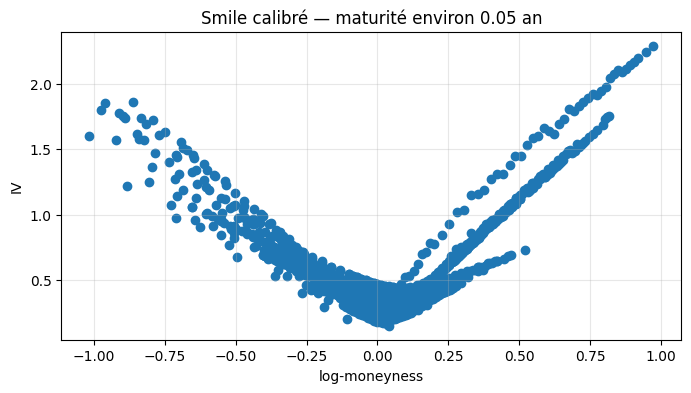

log_moneyness,-0.300000,-0.250000,-0.200000,-0.150000,-0.100000,-0.050000,0.000000,0.050000,0.100000,0.150000,0.200000,0.250000,0.300000
maturity,,,,,,,,,,,,,
0.250000,0.765000,0.458200,0.500300,0.462500,0.478500,0.390000,0.210500,0.410500,0.250700,0.327600,0.774500,0.434900,0.711800
0.500000,0.765000,0.458200,0.500300,0.462500,0.478500,0.390000,0.210500,0.410500,0.250700,0.327600,0.774500,0.434900,0.711800
0.750000,0.765000,0.458200,0.500300,0.462500,0.478500,0.390000,0.210500,0.410500,0.250700,0.327600,0.774500,0.434900,0.711800
1.000000,0.765000,0.458200,0.500300,0.462500,0.478500,0.390000,0.210500,0.410500,0.250700,0.327600,0.774500,0.434900,0.711800
1.250000,0.765000,0.458200,0.500300,0.462500,0.478500,0.390000,0.210500,0.410500,0.250700,0.327600,0.774500,0.434900,0.711800
1.500000,0.765000,0.458200,0.500300,0.462500,0.478500,0.390000,0.210500,0.410500,0.250700,0.327600,0.774500,0.434900,0.711800
1.750000,0.765000,0.458200,0.500300,0.462500,0.478500,0.390000,0.210500,0.410500,0.250700,0.327600,0.774500,0.434900,0.711800
2.000000,0.765000,0.458200,0.500300,0.462500,0.478500,0.390000,0.210500,0.410500,0.250700,0.327600,0.774500,0.434900,0.711800


In [13]:
if not calibrated_quotes.empty and {"time_to_maturity_years", "log_moneyness", "implied_vol"}.issubset(calibrated_quotes.columns):
    first_T = calibrated_quotes["time_to_maturity_years"].dropna().iloc[0]
    smile = calibrated_quotes[np.isclose(calibrated_quotes["time_to_maturity_years"], first_T)]

    plt.figure(figsize=(8, 4))
    plt.scatter(smile["log_moneyness"], smile["implied_vol"])
    plt.title(f"Smile calibré — maturité environ {first_T:.2f} an")
    plt.xlabel("log-moneyness")
    plt.ylabel("IV")
    plt.grid(True, alpha=0.3)
    plt.show()

    if build_surface_grid is not None and hasattr(vol_surface, "volatility"):
        try:
            grid = build_surface_grid(
                vol_surface,
                maturity_grid=np.linspace(0.25, 2.0, 8),
                log_moneyness_grid=np.linspace(-0.30, 0.30, 13),
            )
            display(grid.pivot(index="maturity", columns="log_moneyness", values="implied_vol").round(4))
        except Exception as exc:
            print("Surface grid indisponible:", exc)
else:
    print("Pas de smile affichable.")


## 10. Factory et routeur

### Attendu

- `BasisSwap` → `DiscountingModel`.
- `AutocallProduct` → `MonteCarloGBMModel`.
- Stratégies optionnelles → `StaticReplicationModel`.
- Vanilles → `BlackScholesModel`.


In [14]:
def row_spot_reference(row: pd.Series) -> float:
    for key in ["spot_reference", "initial_spot", "spot", "underlying_price"]:
        value = row.get(key, np.nan)
        try:
            if pd.notna(value):
                return float(value)
        except Exception:
            pass
    underlying = str(row.get("underlying", "")).upper()
    return float(spot_by_underlying.get(underlying, 100.0))

def build_router(n_paths: int = 20_000):
    if PricingRouter is None:
        return None

    return PricingRouter.with_defaults(
        rate=DEFAULT_RATE,
        volatility=DEFAULT_VOL,
        dividend_yield=DEFAULT_DIVIDEND_YIELD,
        yield_curve=yield_curve,
        vol_surface=vol_surface,
        n_paths=n_paths,
        n_steps=252,
        seed=42,
    )

router = build_router()

catalog = []
for idx, row in inventory_all.iterrows():
    try:
        product = build_product_from_row(row, spot_reference=row_spot_reference(row))
        model = router.model_for(product) if router is not None else None
        catalog.append({
            "product_id": getattr(product, "product_id", row.get("product_id", idx)),
            "source_sheet": row.get("source_sheet", ""),
            "product_type": row.get("product_type", ""),
            "product_class": type(product).__name__,
            "model_class": type(model).__name__ if model is not None else None,
            "maturity": getattr(product, "maturity", np.nan),
            "notional": getattr(product, "notional", np.nan),
            "position_sign": row.get("position_sign", np.nan),
            "status": "OK",
            "details": "",
        })
    except Exception as exc:
        catalog.append({
            "product_id": row.get("product_id", idx),
            "source_sheet": row.get("source_sheet", ""),
            "product_type": row.get("product_type", ""),
            "product_class": None,
            "model_class": None,
            "maturity": np.nan,
            "notional": np.nan,
            "position_sign": row.get("position_sign", np.nan),
            "status": "WARN",
            "details": str(exc),
        })

catalog_df = pd.DataFrame(catalog)
display(catalog_df)


,product_id,source_sheet,product_type,product_class,model_class,maturity,notional,position_sign,status,details
0,IRS-1,swaps,Interest Rate Swap,InterestRateSwap,DiscountingModel,0.840520,"1,000,000.000000",1.000000,OK,
1,IRS-2,swaps,Interest Rate Swap,InterestRateSwap,DiscountingModel,1.839836,"3,000,000.000000",1.000000,OK,
2,IRS-3,swaps,Interest Rate Swap,InterestRateSwap,DiscountingModel,1.839836,"500,000.000000",1.000000,OK,
3,BASIS-4,swaps,Basis Swap,BasisSwap,DiscountingModel,6.422998,"5,000,000.000000",1.000000,OK,
4,IRS-5,swaps,Interest Rate Swap,InterestRateSwap,DiscountingModel,24.840520,"5,500,000.000000",1.000000,OK,
5,CS-2,options,Call Spread,CallSpread,StaticReplicationModel,0.084873,"100,000.000000",1.000000,OK,
6,BF-4,options,Butterfly,Butterfly,StaticReplicationModel,0.336756,"250,000.000000",1.000000,OK,
7,CALL-BARRIER-5,options,Call,BarrierOption,BarrierModel,0.336756,"100,000.000000",1.000000,OK,
8,CS-1,options,Call Spread,CallSpread,StaticReplicationModel,0.336756,"100,000.000000",1.000000,OK,
9,PUT-BARRIER-6,options,Put,BarrierOption,BarrierModel,0.336756,"100,000.000000",1.000000,OK,


## 11. MarketData par ligne

### Attendu

Priorité spot :

1. colonne `spot` ou `underlying_price`;
2. `spot_by_underlying[underlying]`;
3. `100`.


In [15]:
def market_data_for_row(row: pd.Series):
    if MarketData is None:
        return None

    underlying = str(row.get("underlying", "")).upper()

    spot = np.nan
    for key in ["spot", "underlying_price"]:
        value = row.get(key, np.nan)
        try:
            if pd.notna(value):
                spot = float(value)
                break
        except Exception:
            pass

    rate = row.get("rate", np.nan)
    vol = row.get("volatility", np.nan)
    div = row.get("dividend_yield", DEFAULT_DIVIDEND_YIELD)

    spot = float(spot) if pd.notna(spot) else float(spot_by_underlying.get(underlying, 100.0))
    rate = float(rate) if pd.notna(rate) else DEFAULT_RATE
    vol = float(vol) if pd.notna(vol) else float(vol_by_underlying.get(underlying, DEFAULT_VOL))
    div = float(div) if pd.notna(div) else DEFAULT_DIVIDEND_YIELD

    return MarketData(
        spot=spot,
        rate=rate,
        volatility=vol,
        dividend_yield=div,
    )

market_debug_rows = []
for idx, row in inventory_all.iterrows():
    md_row = market_data_for_row(row)
    market_debug_rows.append({
        "product_id": row.get("product_id", idx),
        "underlying": row.get("underlying", ""),
        "spot_used": md_row.spot if md_row is not None else np.nan,
        "rate_used": md_row.rate if md_row is not None else np.nan,
        "volatility_used": md_row.volatility if md_row is not None else np.nan,
    })

display(pd.DataFrame(market_debug_rows))


,product_id,underlying,spot_used,rate_used,volatility_used
0,NaN,NaN,100.000000,0.030000,0.200000
1,NaN,NaN,100.000000,0.030000,0.200000
2,NaN,NaN,100.000000,0.030000,0.200000
3,NaN,NaN,100.000000,0.030000,0.200000
4,NaN,NaN,100.000000,0.030000,0.200000
5,NaN,AAPL,257.460000,0.030000,0.391845
6,NaN,AAPL,257.460000,0.030000,0.391845
7,NaN,AAPL,257.460000,0.030000,0.391845
8,NaN,AAPL,257.460000,0.030000,0.391845
9,NaN,AAPL,257.460000,0.030000,0.391845


## 12. Validations financières

### Attendu

Les tests disponibles doivent être `PASS`.

Les validations les plus importantes :

- call-put parity ;
- call-spread flat-vs-flat ;
- call-spread surface-vs-surface ;
- KO + KI = vanilla ;
- MC ≈ Black-Scholes ;
- ZCB discounting ;
- BasisSwap priceable ;
- numerical Greeks ≈ Black-Scholes.


In [16]:
validation_rows = []

# 1. Parité call-put
try:
    S, K, T, r, q, sigma = 100.0, 100.0, 1.0, DEFAULT_RATE, DEFAULT_DIVIDEND_YIELD, DEFAULT_VOL
    call = black_scholes_price_and_greeks(option_type="call", spot=S, strike=K, maturity=T, rate=r, volatility=sigma, dividend_yield=q).price
    put = black_scholes_price_and_greeks(option_type="put", spot=S, strike=K, maturity=T, rate=r, volatility=sigma, dividend_yield=q).price
    lhs = call + K * math.exp(-r * T)
    rhs = put + S * math.exp(-q * T)
    validation_rows.append(compare_value("Call-put parity", lhs, rhs, 1e-8))
except Exception as exc:
    validation_rows.append({"check": "Call-put parity", "status": "SKIP", "details": str(exc)})

# 2. Call spread flat
try:
    md0 = MarketData(spot=100.0, rate=DEFAULT_RATE, volatility=DEFAULT_VOL, dividend_yield=0.0)
    bs = BlackScholesModel(rate=DEFAULT_RATE, volatility=DEFAULT_VOL)

    static_flat = StaticReplicationModel(
        rate=DEFAULT_RATE,
        volatility=DEFAULT_VOL,
        dividend_yield=0.0,
        yield_curve=None,
        vol_surface=None,
    )

    cs = CallSpread("CS-VALID", maturity=1.0, strike_low=95.0, strike_high=110.0, underlying="MSFT", notional=1.0)
    cs_price = static_flat.price(cs, md0)

    c1 = VanillaOption("C95", "call", 95.0, 1.0)
    c2 = VanillaOption("C110", "call", 110.0, 1.0)
    expected = bs.price(c1, md0) - bs.price(c2, md0)

    validation_rows.append(compare_value("Call spread flat BS", cs_price, expected, 1e-8))
except Exception as exc:
    validation_rows.append({"check": "Call spread flat BS", "status": "SKIP", "details": str(exc)})

# 3. Call spread surface
try:
    md0 = MarketData(
        spot=spot_by_underlying.get("AAPL", 100.0),
        rate=DEFAULT_RATE,
        volatility=vol_by_underlying.get("AAPL", DEFAULT_VOL),
        dividend_yield=0.0,
    )

    static_surface = StaticReplicationModel(
        rate=DEFAULT_RATE,
        volatility=DEFAULT_VOL,
        dividend_yield=0.0,
        yield_curve=yield_curve,
        vol_surface=vol_surface,
    )

    cs = CallSpread("CS-SURFACE", maturity=0.336756, strike_low=260.0, strike_high=280.0, underlying="AAPL", notional=1.0)
    cs_price = static_surface.price(cs, md0)

    expected = 0.0
    for option, quantity in cs.get_legs():
        expected += quantity * static_surface._price_option_result(option, md0).price

    validation_rows.append(compare_value("Call spread surface legs", cs_price, expected, 1e-8))
except Exception as exc:
    validation_rows.append({"check": "Call spread surface legs", "status": "SKIP", "details": str(exc)})

# 4. Barrière
try:
    md0 = MarketData(spot=100.0, rate=DEFAULT_RATE, volatility=DEFAULT_VOL, dividend_yield=0.0)
    barrier_model = BarrierModel(rate=DEFAULT_RATE, volatility=DEFAULT_VOL)
    bs = BlackScholesModel(rate=DEFAULT_RATE, volatility=DEFAULT_VOL)

    ko = BarrierOption("PUT-KO", "put", 100.0, 1.0, barrier=80.0, barrier_type="KO", barrier_direction="down")
    ki = BarrierOption("PUT-KI", "put", 100.0, 1.0, barrier=80.0, barrier_type="KI", barrier_direction="down")
    vanilla = VanillaOption("PUT-V", "put", 100.0, 1.0)

    obtained = barrier_model.price(ko, md0) + barrier_model.price(ki, md0)
    expected = bs.price(vanilla, md0)
    validation_rows.append(compare_value("Barrier parity KO+KI=vanilla", obtained, expected, 1e-8))
except Exception as exc:
    validation_rows.append({"check": "Barrier parity KO+KI", "status": "SKIP", "details": str(exc)})

# 5. MC vs BS
try:
    md0 = MarketData(spot=100.0, rate=DEFAULT_RATE, volatility=DEFAULT_VOL, dividend_yield=0.0)
    vanilla = VanillaOption("MC-CALL", "call", 100.0, 1.0)
    bs_price = BlackScholesModel(rate=DEFAULT_RATE, volatility=DEFAULT_VOL).price(vanilla, md0)
    mc = MonteCarloGBMModel(n_paths=30_000, n_steps=126, seed=42, antithetic=True, rate=DEFAULT_RATE, volatility=DEFAULT_VOL)
    mc_res = mc.price_with_error(vanilla, md0)
    tolerance = max(3.0 * mc_res.standard_error, 0.25)
    validation_rows.append(compare_value("Monte Carlo ≈ Black-Scholes", mc_res.price, bs_price, tolerance))
except Exception as exc:
    validation_rows.append({"check": "Monte Carlo ≈ Black-Scholes", "status": "SKIP", "details": str(exc)})

# 6. ZCB
try:
    md0 = MarketData(spot=100.0, rate=DEFAULT_RATE, volatility=DEFAULT_VOL)
    zcb = ZeroCouponBond("ZCB-VALID", 100_000.0, 2.0)
    disc = DiscountingModel(rate=DEFAULT_RATE)
    obtained = disc.price(zcb, md0)
    expected = 100_000.0 * math.exp(-DEFAULT_RATE * 2.0)
    validation_rows.append(compare_value("ZCB discounting", obtained, expected, 1e-8))
except Exception as exc:
    validation_rows.append({"check": "ZCB discounting", "status": "SKIP", "details": str(exc)})

# 7. BasisSwap
try:
    basis = BasisSwap(
        product_id="BASIS-VALID",
        notional=1_000_000.0,
        maturity=2.0,
        receive_index="6M",
        pay_index="3M",
        spread=0.001,
    )
    disc = DiscountingModel(rate=DEFAULT_RATE)
    price = disc.price(basis, MarketData(rate=DEFAULT_RATE, spot=100.0, volatility=DEFAULT_VOL))
    validation_rows.append({
        "check": "BasisSwap priceable",
        "obtained": price,
        "expected": "finite float",
        "abs_diff": np.nan,
        "tolerance": np.nan,
        "status": "PASS" if np.isfinite(price) else "WARN",
    })
except Exception as exc:
    validation_rows.append({"check": "BasisSwap priceable", "status": "SKIP", "details": str(exc)})

# 8. Numerical Greeks vs BS
try:
    product = VanillaOption("CHK-CALL", "call", 100.0, 1.0)
    market = MarketData(spot=100.0, rate=DEFAULT_RATE, volatility=DEFAULT_VOL, dividend_yield=0.0)
    model = BlackScholesModel(rate=DEFAULT_RATE, volatility=DEFAULT_VOL)
    analytical = model.risk(product, market)
    numerical = NumericalGreeksEngine(
        NumericalGreeksConfig(
            spot_relative_bump=1e-4,
            volatility_bump=1e-4,
            rate_bump=1e-4,
            compute_theta=False,
        )
    ).greeks(product, model, market)

    validation_rows.append(compare_value("Numerical delta ≈ BS delta", numerical["delta"], analytical["delta"], 1e-4))
    validation_rows.append(compare_value("Numerical gamma ≈ BS gamma", numerical["gamma"], analytical["gamma"], 1e-4))
    validation_rows.append(compare_value("Numerical vega ≈ BS vega", numerical["vega"], analytical["vega"], 1e-2))
    validation_rows.append(compare_value("Numerical rho ≈ BS rho", numerical["rho"], analytical["rho"], 1e-2))
except Exception as exc:
    validation_rows.append({"check": "Numerical Greeks vs BS", "status": "SKIP", "details": str(exc)})

validation_df = pd.DataFrame(validation_rows)
display(validation_df)


,check,obtained,expected,abs_diff,tolerance,status
0,Call-put parity,106.457957,106.457957,0.000000,0.000000,PASS
1,Call spread flat BS,6.886304,6.886304,0.000000,0.000000,PASS
2,Call spread surface legs,9.898217,9.898217,0.000000,0.000000,PASS
3,Barrier parity KO+KI=vanilla,6.457957,6.457957,0.000000,0.000000,PASS
4,Monte Carlo ≈ Black-Scholes,9.295454,9.413403,0.117949,0.250000,PASS
5,ZCB discounting,"94,176.453358","94,176.453358",0.000000,0.000000,PASS
6,BasisSwap priceable,"1,926.659744",finite float,NaN,NaN,PASS
7,Numerical delta ≈ BS delta,0.598706,0.598706,0.000000,0.000100,PASS
8,Numerical gamma ≈ BS gamma,0.019333,0.019333,0.000000,0.000100,PASS
9,Numerical vega ≈ BS vega,38.666812,38.666812,0.000000,0.010000,PASS


## 13. Pricing portefeuille sans puis avec Greeks numériques

### Attendu

- Le pricing sans Greeks numériques peut avoir des Greeks nuls sur barrières/autocalls.
- Le pricing avec Greeks numériques doit avoir `numerical_greeks_used = 1` sur les produits ciblés.


In [17]:
base_config = PortfolioPricingConfig(
    default_spot=100.0,
    default_rate=DEFAULT_RATE,
    default_volatility=DEFAULT_VOL,
    dividend_yield=DEFAULT_DIVIDEND_YIELD,
    spot_by_underlying=spot_by_underlying,
    volatility_by_underlying=vol_by_underlying,
    n_paths=20_000,
    n_steps=252,
    seed=42,
)

engine_analytic = PortfolioPricingEngine(
    config=base_config,
    yield_curve=yield_curve,
    vol_surface=vol_surface,
    use_numerical_greeks=False,
)

priced_analytic = engine_analytic.price_portfolio(inventory_all)

num_engine = NumericalGreeksEngine(
    NumericalGreeksConfig(
        spot_relative_bump=1e-4,
        volatility_bump=1e-4,
        rate_bump=1e-4,
        theta_bump_years=1.0 / 365.25,
        compute_theta=True,
        only_fill_missing_or_zero=True,
    )
)

engine_num = PortfolioPricingEngine(
    config=base_config,
    yield_curve=yield_curve,
    vol_surface=vol_surface,
    numerical_greeks_engine=num_engine,
    use_numerical_greeks=True,
    numerical_greeks_for=("BarrierOption", "AutocallProduct"),
)

priced_portfolio = engine_num.price_portfolio(inventory_all)

safe_head("Pricing analytique / modèle", priced_analytic, 40)
safe_head("Pricing avec Greeks numériques", priced_portfolio, 40)



--- Pricing analytique / modèle ---


,line_index,source_sheet,source_row,portfolio,product_id,product_type,underlying,pricing_status_hint,product_class,model_name,status,price,delta,gamma,vega,theta,rho,dv01,standard_error,ci_low,ci_high,maturity_years,strike,maturity_bucket,strike_bucket,spot_used,rate_used,volatility_used,position_sign,numerical_greeks_used,numerical_greeks_error,error_message
0,0,swaps,1,default,IRS-1,Interest Rate Swap,<NA>,ok,InterestRateSwap,DiscountingModel,priced,"7,218.140646",0.000000,0.000000,0.000000,0.000000,"835,059.253056",-83.505925,NaN,NaN,NaN,0.840520,NaN,6M-1Y,NA,100.000000,0.030000,0.200000,1.000000,0.000000,,
1,1,swaps,2,default,IRS-2,Interest Rate Swap,<NA>,ok,InterestRateSwap,DiscountingModel,priced,"217,018.887164",0.000000,0.000000,0.000000,0.000000,"5,661,158.100776",-566.115810,NaN,NaN,NaN,1.839836,NaN,1Y-2Y,NA,100.000000,0.030000,0.200000,1.000000,0.000000,,
2,2,swaps,3,default,IRS-3,Interest Rate Swap,<NA>,ok,InterestRateSwap,DiscountingModel,priced,"45,755.431549",0.000000,0.000000,0.000000,0.000000,"955,039.647065",-95.503965,NaN,NaN,NaN,1.839836,NaN,1Y-2Y,NA,100.000000,0.030000,0.200000,1.000000,0.000000,,
3,3,swaps,4,default,BASIS-4,Basis Swap,<NA>,ok,BasisSwap,DiscountingModel,priced,0.000000,0.000000,0.000000,0.000000,0.000000,0.000037,-0.000000,NaN,NaN,NaN,6.422998,NaN,5Y-10Y,NA,100.000000,0.030000,0.200000,1.000000,0.000000,,
4,4,swaps,5,default,IRS-5,Interest Rate Swap,<NA>,ok,InterestRateSwap,DiscountingModel,priced,"1,239,989.969468",0.000000,0.000000,0.000000,0.000000,"93,633,815.484215","-9,363.381548",NaN,NaN,NaN,24.840520,NaN,10Y+,NA,100.000000,0.030000,0.200000,1.000000,0.000000,,
5,5,options,2,default,CS-2,Call Spread,AAPL,nan,CallSpread,StaticReplicationModel,priced,"2,078,346.735313","57,884.587707",-153.105257,"404,243.251877","-2,675,194.159944","1,088,468.708243",0.000000,NaN,NaN,NaN,0.084873,260.000000,0-6M,atm,257.460000,0.030000,0.391845,1.000000,0.000000,,
6,6,options,4,default,BF-4,Butterfly,AAPL,nan,Butterfly,StaticReplicationModel,priced,"219,815.116099","12,900.281873",274.420820,"-3,067,793.625325","5,399,531.919916","1,044,444.761031",0.000000,NaN,NaN,NaN,0.336756,226.666667,0-6M,low,257.460000,0.030000,0.391845,1.000000,0.000000,,
7,7,options,5,default,CALL-BARRIER-5,Call,AAPL,nan,BarrierOption,BarrierModel,priced,"194,275.779018",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.336756,260.000000,0-6M,atm,257.460000,0.030000,0.391845,1.000000,0.000000,,
8,8,options,1,default,CS-1,Call Spread,AAPL,nan,CallSpread,StaticReplicationModel,priced,"989,821.520882","17,873.591800",-60.689072,"313,186.806921","-605,004.691697","1,216,332.241305",0.000000,NaN,NaN,NaN,0.336756,270.000000,0-6M,atm,257.460000,0.030000,0.391845,1.000000,0.000000,,
9,9,options,6,default,PUT-BARRIER-6,Put,AAPL,nan,BarrierOption,BarrierModel,priced,"1,096,892.012276",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.336756,260.000000,0-6M,atm,257.460000,0.030000,0.391845,1.000000,0.000000,,


shape = (16, 32)

--- Pricing avec Greeks numériques ---


,line_index,source_sheet,source_row,portfolio,product_id,product_type,underlying,pricing_status_hint,product_class,model_name,status,price,delta,gamma,vega,theta,rho,dv01,standard_error,ci_low,ci_high,maturity_years,strike,maturity_bucket,strike_bucket,spot_used,rate_used,volatility_used,position_sign,numerical_greeks_used,numerical_greeks_error,error_message
0,0,swaps,1,default,IRS-1,Interest Rate Swap,<NA>,ok,InterestRateSwap,DiscountingModel,priced,"7,218.140646",0.000000,0.000000,0.000000,0.000000,"835,059.253056",-83.505925,NaN,NaN,NaN,0.840520,NaN,6M-1Y,NA,100.000000,0.030000,0.200000,1.000000,0.000000,,
1,1,swaps,2,default,IRS-2,Interest Rate Swap,<NA>,ok,InterestRateSwap,DiscountingModel,priced,"217,018.887164",0.000000,0.000000,0.000000,0.000000,"5,661,158.100776",-566.115810,NaN,NaN,NaN,1.839836,NaN,1Y-2Y,NA,100.000000,0.030000,0.200000,1.000000,0.000000,,
2,2,swaps,3,default,IRS-3,Interest Rate Swap,<NA>,ok,InterestRateSwap,DiscountingModel,priced,"45,755.431549",0.000000,0.000000,0.000000,0.000000,"955,039.647065",-95.503965,NaN,NaN,NaN,1.839836,NaN,1Y-2Y,NA,100.000000,0.030000,0.200000,1.000000,0.000000,,
3,3,swaps,4,default,BASIS-4,Basis Swap,<NA>,ok,BasisSwap,DiscountingModel,priced,0.000000,0.000000,0.000000,0.000000,0.000000,0.000037,-0.000000,NaN,NaN,NaN,6.422998,NaN,5Y-10Y,NA,100.000000,0.030000,0.200000,1.000000,0.000000,,
4,4,swaps,5,default,IRS-5,Interest Rate Swap,<NA>,ok,InterestRateSwap,DiscountingModel,priced,"1,239,989.969468",0.000000,0.000000,0.000000,0.000000,"93,633,815.484215","-9,363.381548",NaN,NaN,NaN,24.840520,NaN,10Y+,NA,100.000000,0.030000,0.200000,1.000000,0.000000,,
5,5,options,2,default,CS-2,Call Spread,AAPL,nan,CallSpread,StaticReplicationModel,priced,"2,078,346.735313","57,884.587707",-153.105257,"404,243.251877","-2,675,194.159944","1,088,468.708243",0.000000,NaN,NaN,NaN,0.084873,260.000000,0-6M,atm,257.460000,0.030000,0.391845,1.000000,0.000000,,
6,6,options,4,default,BF-4,Butterfly,AAPL,nan,Butterfly,StaticReplicationModel,priced,"219,815.116099","12,900.281873",274.420820,"-3,067,793.625325","5,399,531.919916","1,044,444.761031",0.000000,NaN,NaN,NaN,0.336756,226.666667,0-6M,low,257.460000,0.030000,0.391845,1.000000,0.000000,,
7,7,options,5,default,CALL-BARRIER-5,Call,AAPL,nan,BarrierOption,BarrierModel,priced,"194,275.779018",-529.002693,-403.521203,"-1,927,572.384385","550,917.592398",0.000000,0.000000,NaN,NaN,NaN,0.336756,260.000000,0-6M,atm,257.460000,0.030000,0.391845,1.000000,1.000000,,
8,8,options,1,default,CS-1,Call Spread,AAPL,nan,CallSpread,StaticReplicationModel,priced,"989,821.520882","17,873.591800",-60.689072,"313,186.806921","-605,004.691697","1,216,332.241305",0.000000,NaN,NaN,NaN,0.336756,270.000000,0-6M,atm,257.460000,0.030000,0.391845,1.000000,0.000000,,
9,9,options,6,default,PUT-BARRIER-6,Put,AAPL,nan,BarrierOption,BarrierModel,priced,"1,096,892.012276","-48,829.388208","1,514.082580","6,673,980.685364","-1,518,320.381124",0.000000,0.000000,NaN,NaN,NaN,0.336756,260.000000,0-6M,atm,257.460000,0.030000,0.391845,1.000000,1.000000,,


shape = (16, 32)


## 14. Diagnostics pricing et Greeks

### Attendu

- `ratio prix finis > 80%`.
- Greeks non nuls sur options/notes.
- `numerical_greeks_used > 0` pour barrières/autocalls si présents.


In [18]:
checks = []

checks.append({
    "check": "nombre de produits pricés",
    "observed": len(priced_portfolio),
    "expected": len(inventory_all),
    "status": "PASS" if len(priced_portfolio) == len(inventory_all) else "WARN",
})

price_ratio = finite_ratio(priced_portfolio.get("price", pd.Series(dtype=float)))
checks.append({
    "check": "ratio prix finis",
    "observed": price_ratio,
    "expected": "> 0.80",
    "status": "PASS" if price_ratio > 0.80 else "WARN",
})

error_count = 0
if "status" in priced_portfolio.columns:
    error_count = int((priced_portfolio["status"].astype(str).str.lower() == "error").sum())

checks.append({
    "check": "lignes en erreur",
    "observed": error_count,
    "expected": 0,
    "status": "PASS" if error_count == 0 else "WARN",
})

greek_cols = [c for c in ["delta", "gamma", "vega", "theta", "rho", "dv01"] if c in priced_portfolio.columns]
non_zero_greeks = {
    c: int((pd.to_numeric(priced_portfolio[c], errors="coerce").fillna(0.0).abs() > 1e-12).sum())
    for c in greek_cols
}

checks.append({
    "check": "Greeks non nuls par colonne",
    "observed": non_zero_greeks,
    "expected": "delta/vega sur options, rho/dv01 sur taux",
    "status": "PASS" if any(v > 0 for v in non_zero_greeks.values()) else "WARN",
})

num_used = 0
if "numerical_greeks_used" in priced_portfolio.columns:
    num_used = int((pd.to_numeric(priced_portfolio["numerical_greeks_used"], errors="coerce").fillna(0.0) > 0).sum())

checks.append({
    "check": "Greeks numériques utilisés",
    "observed": num_used,
    "expected": ">= 0, >0 si barrières/autocalls présents",
    "status": "PASS",
})

display(pd.DataFrame(checks))

if "error_message" in priced_portfolio.columns:
    errors = priced_portfolio[priced_portfolio["error_message"].astype(str).str.len() > 0]
    if not errors.empty:
        safe_head("Lignes en erreur", errors[["product_id", "product_type", "product_class", "model_name", "status", "error_message"]], 50)

if "numerical_greeks_used" in priced_portfolio.columns:
    numerical_lines = priced_portfolio[pd.to_numeric(priced_portfolio["numerical_greeks_used"], errors="coerce").fillna(0.0) > 0]
    if not numerical_lines.empty:
        safe_head(
            "Lignes avec Greeks numériques",
            numerical_lines[["product_id", "product_class", "model_name", "price", "delta", "gamma", "vega", "theta", "rho", "numerical_greeks_used"]],
            50,
        )


,check,observed,expected,status
0,nombre de produits pricés,16,16,PASS
1,ratio prix finis,1.000000,> 0.80,PASS
2,lignes en erreur,0,0,PASS
3,Greeks non nuls par colonne,"{'delta': 11, 'gamma': 11, 'vega': 11, 'theta'...","delta/vega sur options, rho/dv01 sur taux",PASS
4,Greeks numériques utilisés,3,">= 0, >0 si barrières/autocalls présents",PASS



--- Lignes avec Greeks numériques ---


,product_id,product_class,model_name,price,delta,gamma,vega,theta,rho,numerical_greeks_used
7,CALL-BARRIER-5,BarrierOption,BarrierModel,"194,275.779018",-529.002693,-403.521203,"-1,927,572.384385","550,917.592398",0.000000,1.000000
9,PUT-BARRIER-6,BarrierOption,BarrierModel,"1,096,892.012276","-48,829.388208","1,514.082580","6,673,980.685364","-1,518,320.381124",0.000000,1.000000
11,1.0,AutocallProduct,MonteCarloGBMModel,77.837853,0.000004,-0.000000,0.214699,-1.643342,0.000000,1.000000


shape = (3, 10)


## 15. Agrégation risque

### Attendu

Les risques sont agrégés par :

```text
underlying × maturity_bucket × strike_bucket
```


In [19]:
aggregation_mode = "fallback"

try:
    if RiskAggregator is None:
        raise ImportError("RiskAggregator indisponible")

    aggregator = RiskAggregator()
    risk_by_pillar = aggregator.aggregate_by_pillar(priced_portfolio)
    aggregation_mode = "RiskAggregator"

except Exception as exc:
    print("Fallback agrégation utilisé.")
    print("Raison:", exc)

    work = priced_portfolio.copy()
    for col in ["underlying", "maturity_bucket", "strike_bucket"]:
        if col not in work.columns:
            work[col] = "NA"

    metrics = [c for c in ["price", "delta", "gamma", "vega", "theta", "rho", "dv01"] if c in work.columns]
    risk_by_pillar = (
        work.groupby(["underlying", "maturity_bucket", "strike_bucket"], dropna=False)[metrics]
        .sum(min_count=1)
        .reset_index()
    )
    risk_by_pillar["line_count"] = (
        work.groupby(["underlying", "maturity_bucket", "strike_bucket"], dropna=False)
        .size()
        .values
    )

print("aggregation_mode:", aggregation_mode)
safe_head("Risque par pilier", risk_by_pillar, 50)


aggregation_mode: RiskAggregator

--- Risque par pilier ---


,underlying,maturity_bucket,strike_bucket,price,delta,gamma,vega,theta,rho,dv01,line_count,gross_price
0,<NA>,10Y+,NA,"1,239,989.969468",0.000000,0.000000,0.000000,0.000000,"93,633,815.484215","-9,363.381548",1,"1,239,989.969468"
1,<NA>,1Y-2Y,NA,"262,774.318713",0.000000,0.000000,0.000000,0.000000,"6,616,197.747841",-661.619775,2,"262,774.318713"
2,<NA>,5Y-10Y,NA,0.000000,0.000000,0.000000,0.000000,0.000000,0.000037,-0.000000,1,0.000000
3,<NA>,6M-1Y,NA,"7,218.140646",0.000000,0.000000,0.000000,0.000000,"835,059.253056",-83.505925,1,"7,218.140646"
4,AAPL,0-6M,atm,"4,359,336.047489","26,399.788605",896.767048,"5,463,838.359776","-4,247,601.640366","2,304,800.949547",0.000000,4,"4,359,336.047489"
5,AAPL,0-6M,low,"219,815.116099","12,900.281873",274.420820,"-3,067,793.625325","5,399,531.919916","1,044,444.761031",0.000000,1,"219,815.116099"
6,AAPL,1Y-2Y,atm,99.440924,0.138676,-0.001971,-50.599795,1.371860,278.730210,0.000000,1,99.440924
7,AAPL,2Y-5Y,atm,109.242922,0.262336,0.001529,60.642596,-3.941229,396.529162,0.000000,1,109.242922
8,AAPL,5Y-10Y,NA,77.837853,0.000004,-0.000000,0.214699,-1.643342,0.000000,0.000000,1,77.837853
9,AAPL,6M-1Y,atm,149.026414,0.109644,-0.000242,-30.983169,39.424153,235.695565,0.000000,2,149.026414


shape = (11, 12)


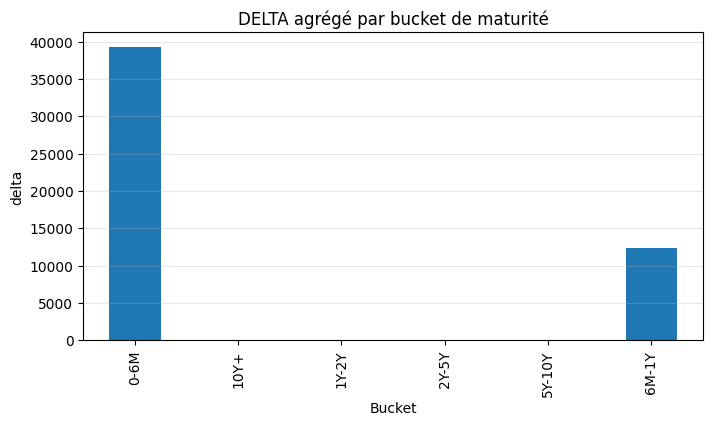

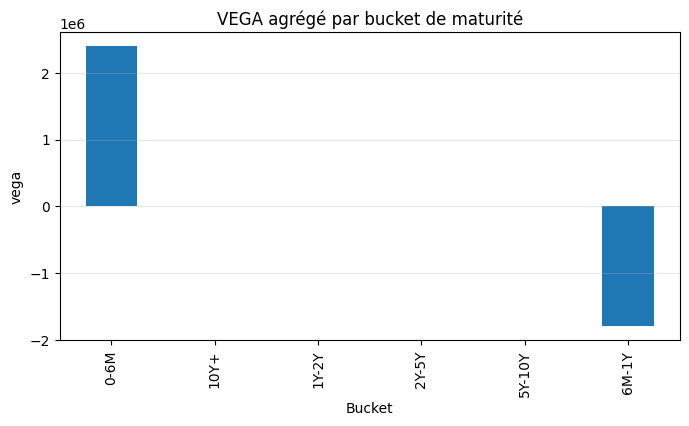

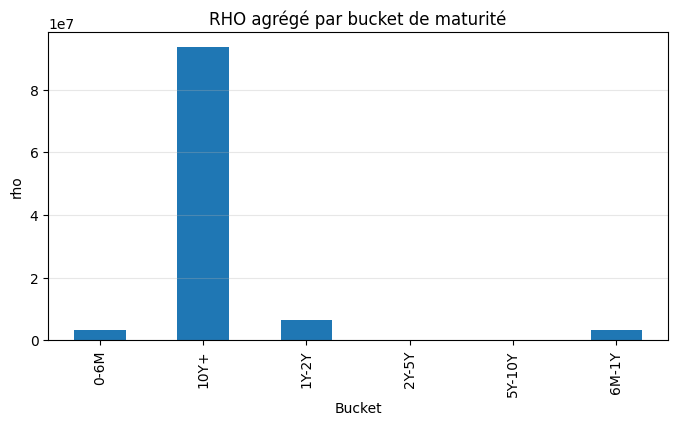

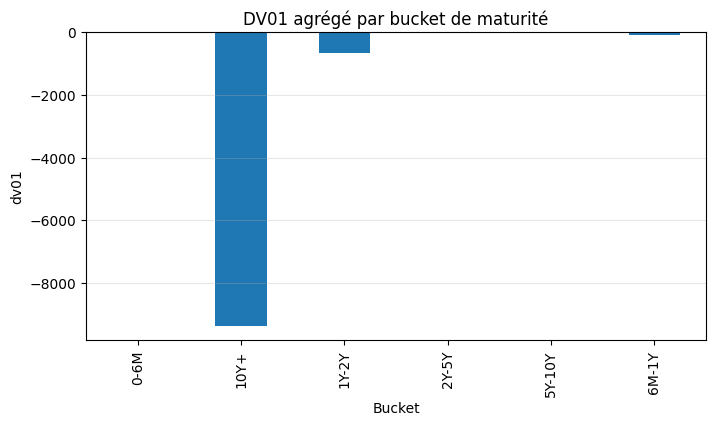

In [20]:
for metric in ["delta", "vega", "rho", "dv01"]:
    if metric in risk_by_pillar.columns:
        series = risk_by_pillar.groupby("maturity_bucket", dropna=False)[metric].sum()
        plt.figure(figsize=(8, 4))
        series.plot(kind="bar")
        plt.title(f"{metric.upper()} agrégé par bucket de maturité")
        plt.xlabel("Bucket")
        plt.ylabel(metric)
        plt.grid(True, axis="y", alpha=0.3)
        plt.show()


## 16. Rapport de risque

### Attendu

Exports CSV créés dans `reports/`.

Si le report est vide, vérifier que `src/risk/report.py` accepte bien :

```text
status in ["priced", "supported"]
```


In [21]:
reports_dir = PROJECT_ROOT / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)

report_mode = "fallback"

try:
    if PortfolioRiskReport is None or RiskSnapshot is None:
        raise ImportError("PortfolioRiskReport ou RiskSnapshot indisponible")

    snapshot = RiskSnapshot.from_priced_portfolio(
        priced_portfolio,
        valuation_date=pd.Timestamp.today().normalize(),
        name="notebook_application_demo_v3",
    )

    report = PortfolioRiskReport([snapshot])
    report_summary = report.to_dataframe()
    exported_paths = report.export_csv(reports_dir / "notebook_application_demo_v3_risk_report.csv")
    report_mode = "PortfolioRiskReport"

except Exception as exc:
    print("Fallback rapport utilisé.")
    print("Raison:", exc)

    report_summary = pd.DataFrame({
        "metric": ["portfolio_value", "net_delta", "net_gamma", "net_vega", "net_theta", "net_rho", "net_dv01", "line_count"],
        "value": [
            pd.to_numeric(priced_portfolio.get("price", pd.Series(dtype=float)), errors="coerce").sum(),
            pd.to_numeric(priced_portfolio.get("delta", pd.Series(dtype=float)), errors="coerce").sum(),
            pd.to_numeric(priced_portfolio.get("gamma", pd.Series(dtype=float)), errors="coerce").sum(),
            pd.to_numeric(priced_portfolio.get("vega", pd.Series(dtype=float)), errors="coerce").sum(),
            pd.to_numeric(priced_portfolio.get("theta", pd.Series(dtype=float)), errors="coerce").sum(),
            pd.to_numeric(priced_portfolio.get("rho", pd.Series(dtype=float)), errors="coerce").sum(),
            pd.to_numeric(priced_portfolio.get("dv01", pd.Series(dtype=float)), errors="coerce").sum(),
            len(priced_portfolio),
        ],
    })

    priced_path = reports_dir / "notebook_v3_priced_portfolio.csv"
    risk_path = reports_dir / "notebook_v3_risk_by_pillar.csv"
    summary_path = reports_dir / "notebook_v3_risk_summary.csv"

    priced_portfolio.to_csv(priced_path, index=False)
    risk_by_pillar.to_csv(risk_path, index=False)
    report_summary.to_csv(summary_path, index=False)

    exported_paths = {
        "priced_portfolio": priced_path,
        "risk_by_pillar": risk_path,
        "summary": summary_path,
    }

print("report_mode:", report_mode)
display(report_summary)

print("Exports:")
if isinstance(exported_paths, dict):
    for key, path in exported_paths.items():
        print(f"- {key}: {path}")
else:
    print(exported_paths)


report_mode: PortfolioRiskReport


,snapshot,valuation_date,price,line_count,delta,gamma,vega,theta,rho,dv01
0,notebook_application_demo_v3,2026-04-28,"4,853,370.815093",16,"51,624.660975","1,095.844901","596,241.737818","1,881,074.660464","107,030,625.517095","-10,108.507249"


Exports:
- summary: C:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Produits Structurés\Projet\structured-products-pricer\reports\notebook_application_demo_v3_risk_report.csv
- portfolio_greeks: C:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Produits Structurés\Projet\structured-products-pricer\reports\notebook_application_demo_v3_risk_report_portfolio_greeks.csv
- top_exposures: C:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Produits Structurés\Projet\structured-products-pricer\reports\notebook_application_demo_v3_risk_report_top_exposures.csv
- pnl_attribution: C:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Produits Structurés\Projet\structured-products-pricer\reports\notebook_application_demo_v3_risk_report_pnl_attribution.csv


## 17. Stress tests finalisés

### Scénarios

- central ;
- spot +10 % ;
- spot -10 % ;
- volatilité +5 points ;
- taux +100 bps ;
- stress equity : spot -15 %, vol +10 points, taux +50 bps.

### Attendu

- Spot stress : P&L surtout sur options/notes/autocalls.
- Vol stress : P&L surtout sur options/notes/barrières/autocalls.
- Rate stress : P&L surtout sur produits de taux, ZCB, notes.


In [22]:
if StressTester is None or StressScenario is None:
    raise ImportError("StressTester / StressScenario indisponibles. Ajouter src/risk/stress_testing.py.")

stress_tester = StressTester(
    base_config=base_config,
    yield_curve=yield_curve,
    vol_surface=vol_surface,
    numerical_greeks_engine=num_engine,
    use_numerical_greeks=True,
    numerical_greeks_for=("BarrierOption", "AutocallProduct"),
)

stress_result = stress_tester.run(
    inventory_all,
    scenarios=[
        StressScenario("central"),
        StressScenario("spot_up_10pct", spot_shock=0.10),
        StressScenario("spot_down_10pct", spot_shock=-0.10),
        StressScenario("vol_up_5pts", vol_shock=0.05),
        StressScenario("rates_up_100bps", rate_shock=0.01),
        StressScenario("equity_stress", spot_shock=-0.15, vol_shock=0.10, rate_shock=0.005),
    ],
)

safe_head("Stress scenario summary", stress_result.scenario_summary, 20)
safe_head("Stress P&L by position", stress_result.pnl_by_position, 50)



--- Stress scenario summary ---


,scenario,price,delta,gamma,vega,theta,rho,dv01,line_count,pnl_vs_base,base_scenario
0,central,"4,853,370.815093","51,624.660975","1,095.844901","596,241.737818","1,881,074.660464","107,030,625.517095","-10,108.507249",16,0.000000,central
1,equity_stress,"4,944,866.576198","-30,609.732375","1,242.023909","1,508,722.574294","1,564,084.099429","96,338,301.026010","-9,242.692544",16,"91,495.761105",central
2,rates_up_100bps,"3,945,228.119594","52,695.088527","1,060.386523","401,112.615129","1,852,770.536167","90,569,334.767289","-8,465.015452",16,"-908,142.695499",central
3,spot_down_10pct,"5,635,328.543784","-15,177.914015","2,670.996113","2,477,643.783729","-1,328,852.677364","104,563,582.131339","-10,108.507249",16,"781,957.728691",central
4,spot_up_10pct,"9,101,160.895541","25,472.594129","-1,395.981584","-707,812.445212","-490,464.120661","102,722,565.363625","-10,108.507249",16,"4,247,790.080448",central
5,vol_up_5pts,"4,902,738.191870","40,756.285229",867.435355,"1,361,188.116429","1,603,942.590097","106,512,617.506819","-10,108.507249",16,"49,367.376778",central


shape = (6, 11)

--- Stress P&L by position ---


,product_id,product_type,underlying,maturity_bucket,strike_bucket,scenario_price,base_price,scenario,base_scenario,pnl
0,PUT-BARRIER-6,Put,AAPL,0-6M,atm,"1,419,746.465406","1,096,892.012276",vol_up_5pts,central,"322,854.453130"
1,BF-4,Butterfly,AAPL,0-6M,low,"77,201.001313","219,815.116099",vol_up_5pts,central,"-142,614.114786"
2,PS-3,Put Spread,AAPL,6M-1Y,low,"-1,320,396.187805","-1,236,198.325434",vol_up_5pts,central,"-84,197.862370"
3,CALL-BARRIER-5,Call,AAPL,0-6M,atm,"120,046.882399","194,275.779018",vol_up_5pts,central,"-74,228.896619"
4,CS-2,Call Spread,AAPL,0-6M,atm,"2,094,158.115693","2,078,346.735313",vol_up_5pts,central,"15,811.380380"
5,CS-1,Call Spread,AAPL,0-6M,atm,"1,001,564.967053","989,821.520882",vol_up_5pts,central,"11,743.446172"
6,SN-1,Capital Protected Note,AAPL,2Y-5Y,atm,112.285235,109.242922,vol_up_5pts,central,3.042313
7,SN-2,Reverse Convertible,AAPL,1Y-2Y,atm,96.905397,99.440924,vol_up_5pts,central,-2.535527
8,SN-4,Reverse Convertible,AAPL,6M-1Y,atm,95.607715,97.381297,vol_up_5pts,central,-1.773582
9,SN-3,Capped Capital Protected Note,AAPL,6M-1Y,atm,51.884510,51.645116,vol_up_5pts,central,0.239394


shape = (96, 10)


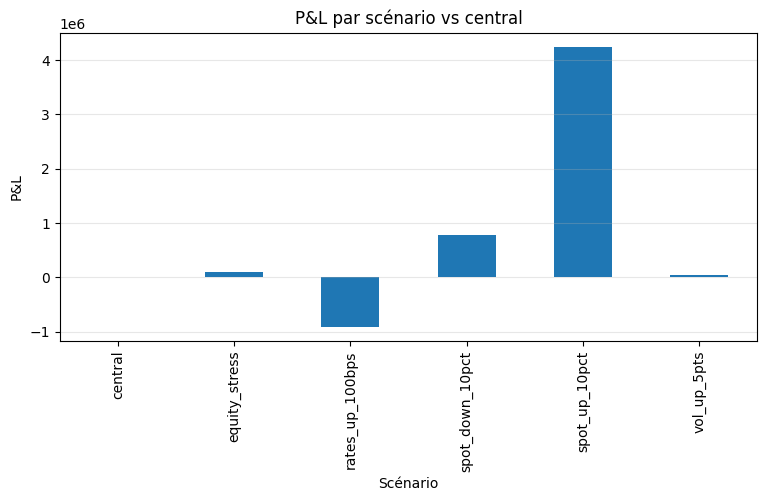

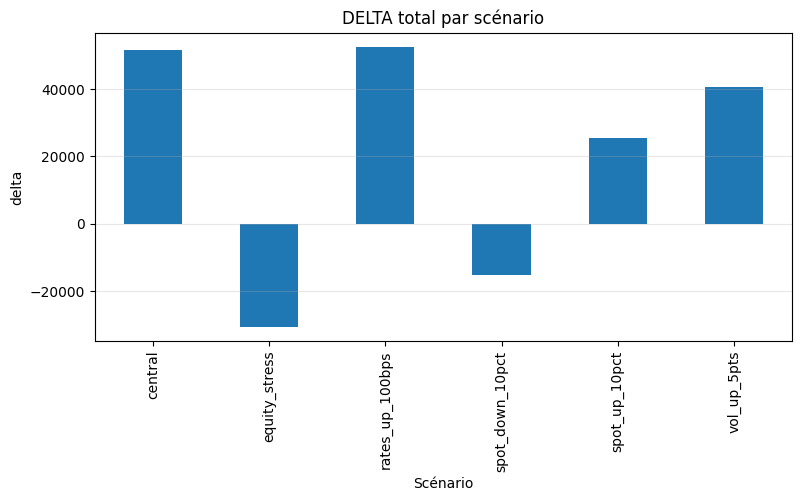

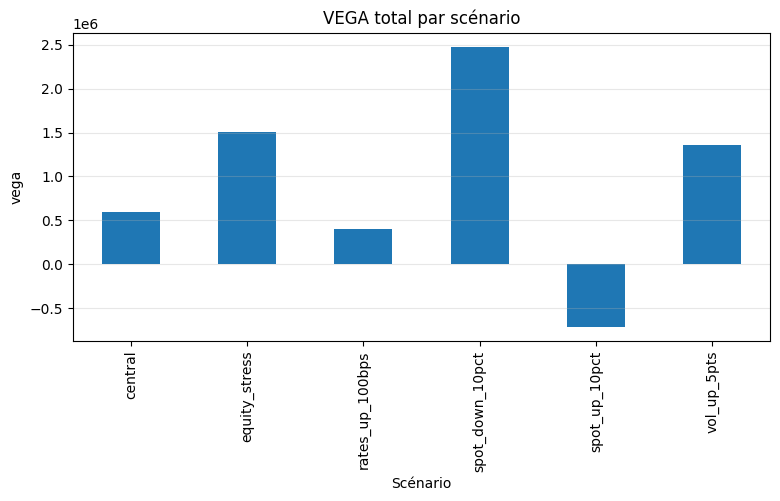

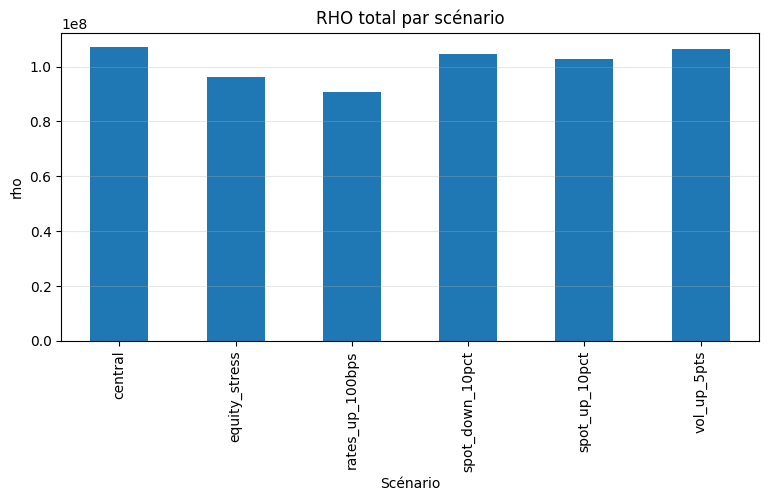

In [23]:
plt.figure(figsize=(9, 4))
stress_result.scenario_summary.set_index("scenario")["pnl_vs_base"].plot(kind="bar")
plt.title("P&L par scénario vs central")
plt.xlabel("Scénario")
plt.ylabel("P&L")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

for metric in ["delta", "vega", "rho"]:
    if metric in stress_result.scenario_summary.columns:
        plt.figure(figsize=(9, 4))
        stress_result.scenario_summary.set_index("scenario")[metric].plot(kind="bar")
        plt.title(f"{metric.upper()} total par scénario")
        plt.xlabel("Scénario")
        plt.ylabel(metric)
        plt.grid(True, axis="y", alpha=0.3)
        plt.show()


## 18. Exports stress tests et dashboard

### Attendu

Les fichiers générés ici peuvent être consommés directement par Streamlit.


In [24]:
exports = {
    "priced_portfolio_with_numerical_greeks": reports_dir / "priced_portfolio_with_numerical_greeks.csv",
    "risk_by_pillar_with_numerical_greeks": reports_dir / "risk_by_pillar_with_numerical_greeks.csv",
    "stress_test_line_results": reports_dir / "stress_test_line_results.csv",
    "stress_test_summary": reports_dir / "stress_test_summary.csv",
    "stress_test_pnl_by_position": reports_dir / "stress_test_pnl_by_position.csv",
}

priced_portfolio.to_csv(exports["priced_portfolio_with_numerical_greeks"], index=False)
risk_by_pillar.to_csv(exports["risk_by_pillar_with_numerical_greeks"], index=False)
stress_result.line_results.to_csv(exports["stress_test_line_results"], index=False)
stress_result.scenario_summary.to_csv(exports["stress_test_summary"], index=False)
stress_result.pnl_by_position.to_csv(exports["stress_test_pnl_by_position"], index=False)

for name, path in exports.items():
    print(f"{name}: {path}")


priced_portfolio_with_numerical_greeks: C:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Produits Structurés\Projet\structured-products-pricer\reports\priced_portfolio_with_numerical_greeks.csv
risk_by_pillar_with_numerical_greeks: C:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Produits Structurés\Projet\structured-products-pricer\reports\risk_by_pillar_with_numerical_greeks.csv
stress_test_line_results: C:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Produits Structurés\Projet\structured-products-pricer\reports\stress_test_line_results.csv
stress_test_summary: C:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Produits Structurés\Projet\structured-products-pricer\reports\stress_test_summary.csv
stress_test_pnl_by_position: C:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Produits Structurés\Projet\structured-products-pricer\reports\stress_test_pnl_by_position.csv


## 19. Interprétation des résultats

### Ce qui doit être cohérent

- `Numerical vega ≈ BS vega` doit être `PASS`.
- `Call spread flat BS` doit être `PASS`.
- `Call spread surface legs` doit être `PASS`.
- Les produits de taux ont souvent `delta = gamma = vega = 0`, mais `rho` / `dv01` non nuls.
- Les `BarrierOption` et `AutocallProduct` doivent avoir `numerical_greeks_used = 1` si présents.
- Les stress tests doivent produire un `pnl_vs_base` non nul sur au moins certains scénarios.

### Ce qui peut rester normal

- Les Greeks numériques Monte Carlo peuvent être bruités.
- Pour les autocalls, augmenter `n_paths` pour stabiliser les Greeks.
- Les prix peuvent différer entre flat vol et surface de vol : c'est attendu.


In [25]:
final_checks = []

final_checks.append({
    "check": "pricing errors",
    "value": int((priced_portfolio["status"].astype(str).str.lower() == "error").sum()) if "status" in priced_portfolio.columns else np.nan,
    "expected": 0,
})

final_checks.append({
    "check": "numerical greeks lines",
    "value": int((pd.to_numeric(priced_portfolio.get("numerical_greeks_used", pd.Series(dtype=float)), errors="coerce").fillna(0.0) > 0).sum()),
    "expected": ">= 0, >0 si barrières/autocalls",
})

final_checks.append({
    "check": "stress scenarios",
    "value": len(stress_result.scenario_summary),
    "expected": 6,
})

final_checks.append({
    "check": "non-zero stress pnl scenarios",
    "value": int((stress_result.scenario_summary["pnl_vs_base"].abs() > 1e-12).sum()),
    "expected": "> 0",
})

display(pd.DataFrame(final_checks))


,check,value,expected
0,pricing errors,0,0
1,numerical greeks lines,3,">= 0, >0 si barrières/autocalls"
2,stress scenarios,6,6
3,non-zero stress pnl scenarios,5,> 0


## 20. Prochaines étapes

Le projet est maintenant prêt pour le dashboard :

- `priced_portfolio` pour la page Portfolio & Pricing ;
- `risk_by_pillar` pour la page Risk ;
- `stress_result.scenario_summary` pour les stress tests ;
- `stress_result.pnl_by_position` pour les top pertes/gains ;
- `report_summary` pour la page Overview.

Améliorations possibles :

1. augmenter `n_paths` à 50k ou 100k pour des Greeks Monte Carlo plus stables ;
2. ajouter des scénarios spécifiques par sous-jacent ;
3. afficher les erreurs de pricing dans une page diagnostics Streamlit ;
4. ajouter une comparaison avant/après Greeks numériques.
